# Nota sobre esta versión

Este notebook analiza la **Encuesta Financiera de Hogares (EFH) 2024** del Banco Central de Chile y es una versión nueva, que no reemplaza a `TareaFinalAEC_aeck.ipynb`. Se agrega como archivo aparte para poder comparar ambas.

**Cómo ejecutarlo.** Hay que dejar el archivo `Base imputada EFH 2024.dta` en la misma carpeta que el notebook. La base no está en el repositorio porque pesa 101 MB y se descarga desde el sitio del Banco Central previo registro. El notebook corre completo en unos 5 minutos y está ejecutado de principio a fin, sin errores.

## Hallazgos sobre la base que condicionan el análisis

Al revisar el archivo aparecieron cuatro asuntos que conviene tener presentes, porque afectan cualquier análisis que se haga con esta base.

1. **El ingreso total es la suma exacta de sus componentes.** En el 100% de los hogares se cumple que `ytoth` es igual a `ylabh + ypenh + ysubh + yotroh + yai`. Si alguna de esas cinco variables entra como predictor, el modelo no predice el ingreso, lo reconstruye.
2. **`estrato` es una versión agrupada del ingreso.** Su etiqueta es "Estrato de ingreso total del hogar" y sus categorías son deciles 1 al 5, 6 al 8 y 9 al 10. Por sí solo explica el 72% de la varianza del logaritmo del ingreso, así que también es fuga de información.
3. **Dos variables tienen etiquetas que no corresponden a sus códigos.** En `neduc_ent` las etiquetas están corridas en un nivel, lo que se comprueba con los años de educación. El código 1 reúne a quienes tienen entre 0 y 8 años de estudio pero está etiquetado como educación diferencial, y el código 5, con 18 a 22 años, aparece como universitaria cuando corresponde a postgrado. En `est_civil_ent` los códigos 8 y 9, que reúnen a 2.097 hogares, no tienen etiqueta, y el promedio de edad por código no calza con el orden etiquetado, así que esa variable se usa solo como código.
4. **Hay códigos y faltantes que no son lo que parecen.** `hr_trabajadas_ent` viene vacía para los 1.569 entrevistados que no están ocupados, que en rigor trabajan 0 horas, y usa -1 para no responde. `ocup_ent` igual a 0 agrupa a todos los que no están ocupados, incluidos inactivos y jubilados, y no solo a los desocupados. Hay 26 hogares con ingreso total igual a cero, los mismos en las 31 réplicas.

## Diferencias con la versión anterior

| Tema | `TareaFinalAEC_aeck.ipynb` | Este notebook |
|---|---|---|
| Variables excluidas del modelo | La lista de exclusión usa nombres que no existen en la EFH (`ing_lab`, `ing_pen`, `ing_cap`, `ytrabajo`, `yjubilacion`), por lo que los componentes del ingreso, el factor de expansión y los ratios con el ingreso en el denominador entran como predictores | Se excluyen `ylabh`, `ypenh`, `ysubh`, `ytotef`, `rci_dt`, `rdi_dt` y `estrato`, y el factor de expansión nunca es predictor |
| Desempeño reportado | Random Forest con R² de 0,994 en prueba, consecuencia de lo anterior | Gradient Boosting con R² de 0,625 en prueba, que es el desempeño real sin fuga |
| Selección del mejor modelo | Los modelos se ordenan por su R² en el conjunto de prueba | Se comparan con validación cruzada de 5 particiones sobre entrenamiento, se ajustan hiperparámetros del mejor y la prueba se usa una sola vez |
| Imputación múltiple | Se usa la réplica 1 | Se usa la réplica 1 y además el modelo final se reentrena en las 30 réplicas para verificar estabilidad |
| Factor de expansión | Queda como una variable predictora más | Se usa como ponderador en los estadísticos que describen a la población y se prueba como `sample_weight` |
| Variables del clúster | Se agrupa con las mismas variables del modelo, que incluyen los componentes del ingreso | Se agrupa solo con montos de deuda y activos, carga financiera y variables del hogar, sin ninguna variable de ingreso |
| Cantidad de grupos | Se fija k = 3 de antemano | Se evalúan de 2 a 10 grupos con codo, silueta, Calinski-Harabasz y Davies-Bouldin, y la regla de elección se declara antes de mirar los resultados |
| Métricas del clúster | Se calculan sobre una proyección de 2 componentes principales | Se calculan sobre el espacio completo de variables estandarizadas, y el PCA se usa solo para visualizar |
| Descripción de los grupos | No se incluye | Se describe cada grupo con estadísticos ponderados y se contrasta con los quintiles de ingreso |
| Exploración | Los gráficos bivariados buscan variables que no existen en la EFH (`educ_max`, `tenencia_vivienda`, `categoria_ocupacional`, `tiene_cta_cte`) y se omiten sin aviso | La exploración usa las variables reales, con distribuciones, atípicos, correlaciones y ANOVA |
| Reproducibilidad | Queda una celda con `KeyError 'ytoth'`, hay celdas con resultados y sin código, y se usa `w_test` sin definirla | Corre de principio a fin sin errores |
| Interpretación | Sin lecturas ni conclusiones | Cada sección tiene su lectura y el notebook cierra con conclusiones y bibliografía |

Lo que sí conviene conservar de la versión anterior es el uso de `ColumnTransformer` con la imputación dentro del pipeline, que es una buena práctica. Aquí no fue necesario porque los faltantes se resuelven antes con reglas explícitas y documentadas.

## Resultados principales de esta versión

- El mejor modelo explica cerca del 63% de la variabilidad del logaritmo del ingreso en datos no vistos, con un error mediano de 29%, y ese desempeño se mantiene en las 30 réplicas de imputación.
- Lo que más predice el ingreso del hogar es cuántos de sus miembros trabajan, seguido del patrimonio, el endeudamiento y los años de educación.
- Sin usar el ingreso, los hogares se separan en dos perfiles, uno fuera del crédito (56% de los hogares) y otro bancarizado y endeudado (44%), y esos perfiles reproducen el ordenamiento por ingreso.
- Unos 180 mil hogares del quintil más pobre quedan en el perfil endeudado y destinan en mediana el 54% de su ingreso mensual a pagar deudas, frente al 24% del conjunto de hogares con deuda.

# **Trabajo Final**
# **Aprendizaje Supervisado y No Supervisado**

**Ramo** Aprendizaje estadístico y computacional

**Integrantes** _(completar)_

**Base de datos** Encuesta Financiera de Hogares (EFH) 2024, Banco Central de Chile. Base abierta, innominada, que se descarga desde el sitio del Banco Central previo registro de usuario.

### Encuesta Financiera de Hogares 2024

La Encuesta Financiera de Hogares es levantada por el Banco Central de Chile cada tres años desde 2007. Recoge información detallada del balance de los hogares, es decir sus ingresos, sus activos (vivienda, vehículos, activos financieros) y sus deudas (hipotecarias y de consumo), junto con la carga financiera que esas deudas representan y las características sociodemográficas del entrevistado. El trabajo de campo de la versión 2024 comenzó en julio de ese año y los resultados se publicaron en septiembre de 2025.

La base publicada tiene dos particularidades que condicionan todo el análisis. La primera es que viene con **imputación múltiple**, de modo que cada hogar aparece varias veces (una por réplica, identificada por la columna `imp`) con los valores faltantes estimados de forma distinta en cada una. La segunda es que cada hogar tiene un **factor de expansión** (`factor`) que indica a cuántos hogares de la población representa, porque la encuesta sobremuestrea a los hogares de mayores ingresos.

### Introducción

En este trabajo uso la EFH 2024 para estudiar el ingreso de los hogares chilenos desde dos ángulos complementarios. En la parte supervisada construyo modelos que predicen el ingreso total del hogar (`ytoth`) a partir de su perfil sociodemográfico, de lo que posee y de lo que debe, y selecciono el mejor según su error de predicción fuera de muestra. En la parte no supervisada agrupo a los hogares solo por su situación patrimonial y demográfica, sin mirar el ingreso, y después reviso si los grupos que aparecen se ordenan o no según el ingreso.

Dejo fuera del modelo las componentes del ingreso (laboral, pensiones, subsidios) y los ratios que tienen el ingreso en el denominador (`rci_dt`, `rdi_dt`), porque incluirlos equivaldría a darle al modelo la respuesta.

### Objetivos

**Objetivo general.** Identificar qué características sociodemográficas, patrimoniales y de endeudamiento se asocian al ingreso de los hogares chilenos en 2024, y descubrir perfiles financieros de hogares que no son evidentes a simple vista.

**Objetivos específicos.**
- Describir la base mediante un análisis exploratorio, tratando la imputación múltiple, los códigos de no respuesta, los valores faltantes, la asimetría y los valores atípicos.
- Entrenar y comparar modelos de regresión para el logaritmo del ingreso total del hogar, seleccionar el mejor con validación cruzada y evaluar su estabilidad entre réplicas de imputación.
- Agrupar a los hogares sin usar el ingreso, elegir la cantidad de grupos con criterios explícitos y describir cada grupo, contrastándolo después con el ingreso.

# PARTE I. EXPLORACIÓN, LIMPIEZA Y PROCESAMIENTO

## 1. Librerías

In [1]:
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             silhouette_score, calinski_harabasz_score,
                             davies_bouldin_score, adjusted_rand_score)
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
SEED = 42

In [2]:
# Funciones auxiliares ponderadas por el factor de expansión
def media_pond(x, w):
    x, w = np.asarray(x, float), np.asarray(w, float)
    m = ~np.isnan(x)
    return np.sum(x[m] * w[m]) / np.sum(w[m])

def mediana_pond(x, w):
    x, w = np.asarray(x, float), np.asarray(w, float)
    m = ~np.isnan(x)
    x, w = x[m], w[m]
    orden = np.argsort(x)
    acum = np.cumsum(w[orden])
    return x[orden][np.searchsorted(acum, acum[-1] / 2)]

def rmse(y, p, w=None):
    return np.sqrt(mean_squared_error(y, p, sample_weight=w))

## 2. Carga de datos

La base se descarga del sitio del Banco Central en formato Stata (`.dta`). La leo dos veces, una con los códigos numéricos, que es la que uso para modelar, y otra con las etiquetas de valor, que uso para que las tablas y gráficos sean legibles. La metadata (etiqueta de cada variable) viene dentro del mismo archivo.

In [3]:
# Busca el archivo de la EFH 2024 en la carpeta del notebook
# La descarga del Banco Central trae varias bases (imputada, no imputada, factores replicados, llave panel).
# Se usa la imputada.
candidatos = [f for f in glob.glob("*[Ii]mputada*EFH*2024*.dta") if "no imputada" not in f.lower()]
if not candidatos:
    raise FileNotFoundError("Falta la base. Descargar la Base imputada EFH 2024 (.dta) desde bcentral.cl "
                            "y dejarla en la misma carpeta que este notebook.")
RUTA = candidatos[0]
print("Archivo:", RUTA)

if RUTA.endswith(".dta"):
    base = pd.read_stata(RUTA, convert_categoricals=False)
    try:
        base_lbl = pd.read_stata(RUTA, convert_categoricals=True)
    except Exception:
        base_lbl = base.copy()
    with pd.io.stata.StataReader(RUTA) as lector:
        etiquetas_var = lector.variable_labels()
else:
    base = pd.read_csv(RUTA)
    base_lbl, etiquetas_var = base.copy(), {}

base.columns = base.columns.str.lower()
base_lbl.columns = base_lbl.columns.str.lower()
print("Dimensiones:", base.shape)

Archivo: Base imputada EFH 2024.dta


Dimensiones: (144119, 123)


In [4]:
# Metadata, etiqueta de cada variable
meta = pd.DataFrame({"variable": base.columns,
                     "descripcion": [etiquetas_var.get(c, etiquetas_var.get(c.upper(), "")) for c in base.columns]})
meta

,variable,descripcion
0,imp,Identificador de imputación
1,id,Identificador de hogar
2,factor,Factor de expansión del hogar
3,genero_ent,Género del entrevistado
4,edad_ent,Edad del entrevistado en años
...,...,...
118,u_cheq,Uso de cheques
119,u_pat,Uso de PAT
120,u_transf,Uso de transferencias mediante internet o telé...
121,u_tprepago,Uso de tarjeta prepago


## 3. Imputación múltiple

A diferencia del ejemplo con NHANES, donde los faltantes se eliminaban con `dropna()`, en la EFH los valores de no respuesta ya fueron estimados por el Banco Central y cada réplica de imputación es una versión completa y plausible de la base. Mezclar réplicas duplicaría artificialmente a cada hogar, de modo que para aplicar los modelos directamente trabajo con **una sola réplica (`imp == 1`)**. Al final de la parte supervisada vuelvo a entrenar el mejor modelo en todas las réplicas para verificar que la conclusión no depende de cuál se eligió.

In [5]:
print("Réplicas de imputación y filas por réplica")
print(base["imp"].value_counts().sort_index())
print("\nHogares distintos:", base["id"].nunique())

Réplicas de imputación y filas por réplica
imp
0.000     4649
1.000     4649
2.000     4649
3.000     4649
4.000     4649
5.000     4649
6.000     4649
7.000     4649
8.000     4649
9.000     4649
10.000    4649
11.000    4649
12.000    4649
13.000    4649
14.000    4649
15.000    4649
16.000    4649
17.000    4649
18.000    4649
19.000    4649
20.000    4649
21.000    4649
22.000    4649
23.000    4649
24.000    4649
25.000    4649
26.000    4649
27.000    4649
28.000    4649
29.000    4649
30.000    4649
Name: count, dtype: int64

Hogares distintos: 4649


In [6]:
IMP_PRINCIPAL = 1
REPLICAS = sorted(r for r in base["imp"].unique() if r != 0)   # imp = 0, si existe, es la base sin imputar

def replica(r, etiquetada=False):
    fuente = base_lbl if etiquetada else base
    return fuente[fuente["imp"] == r].reset_index(drop=True)

df = replica(IMP_PRINCIPAL)
df_lbl = replica(IMP_PRINCIPAL, etiquetada=True)
assert df["id"].is_unique, "Un hogar aparece más de una vez dentro de la réplica"
print("Réplica de trabajo:", df.shape, "| hogares representados:", f"{df['factor'].sum():,.0f}")

Réplica de trabajo: (4649, 123) | hogares representados: 6,693,423


## 4. Clasificación de variables

A partir de la metadata separo las variables en cuatro grupos. Los identificadores y el factor de expansión no entran nunca como predictores. Las variables categóricas se transforman en variables indicadoras (one hot encoding). Las variables de tenencia ya son binarias 0/1.

In [7]:
ID_CONTROL = ["imp", "id", "factor"]
CATEGORICAS = ["genero_ent", "tr_edad_ent", "nacionalidad_ent", "neduc_ent", "est_civil_ent",
               "ocup_ent", "jub_ent", "macrozona", "estrato", "reg_vp"]
BINARIAS = ["t_dhip", "t_tcbco", "t_pbco", "t_dnhip", "t_dtoth", "t_reales", "t_fin",
            "u_efectivo", "u_tdbto", "u_tbco", "u_transf"]
INGRESOS = ["ylabh", "ypenh", "ysubh", "ytoth", "ytotef", "hr_trabajadas_ent"]
DEUDAS = ["d_tothip", "d_nhip", "d_toth", "cf_dtoth", "rci_dt", "rdi_dt"]
ACTIVOS = ["act_vp", "act_vehic", "act_fin", "act_toth"]
HOGAR = ["numh", "ocuph", "edad_ent", "educ_ent"]
NUMERICAS = INGRESOS + DEUDAS + ACTIVOS + HOGAR

# Montos en pesos, muy asimétricos, que se transforman con ln(1 + x)
MONTOS = ["ylabh", "ypenh", "ysubh", "ytoth", "ytotef", "d_tothip", "d_nhip", "d_toth",
          "cf_dtoth", "act_vp", "act_vehic", "act_fin", "act_toth"]

todas = ID_CONTROL + CATEGORICAS + BINARIAS + NUMERICAS
faltan = [c for c in todas if c not in df.columns]
print("Variables esperadas que no están en la base:", faltan or "ninguna")
print("Variables de la base no clasificadas:", [c for c in df.columns if c not in todas] or "ninguna")

Variables esperadas que no están en la base: ninguna
Variables de la base no clasificadas: ['genero_pr', 'edad_pr', 'tr_edad_pr', 'nacionalidad_pr', 'educ_pr', 'neduc_pr', 'est_civil_pr', 'ocup_pr', 'jub_pr', 'hr_trabajadas_pr', 'tr_numh', 'yoprinm_ent', 'yoprinm_pr', 'yoprin_ent', 'yoprin_pr', 'yosec_ent', 'yosec_pr', 'yotroh', 'yai', 't_lcbco', 't_tcc', 't_pcc', 't_caco', 't_dauto', 't_deduc', 't_dotras', 'd_vp', 'd_otp', 'vp_fch', 'otp_fch', 'estado_chvp', 'd_tcbco', 'd_lcbco', 'd_pbco', 'd_tcc', 'd_pcc', 'd_caco', 'd_auto', 'd_educ', 'd_otras', 't_ahcta', 't_otros_ah', 't_atoth', 'act_otp', 'act_otros', 'act_var', 'act_fijo', 'act_ahcta', 'div_vp', 'div_otp', 'cf_dhip', 'cf_dtbco', 'cf_dlbco', 'cf_dpbco', 'cf_dtcc', 'cf_dpcc', 'cf_dcaco', 'cf_dauto', 'cf_deduc', 'cf_dnhip', 'rci_dhip', 'rci_dnhip', 'rdi_dhip', 'rdi_dnhip', 'prevision_ent', 'cotizacion_ent', 'conoc_pen_ent', 'cap_pen_ent', 'conoc_fondo_ent', 't_cc', 't_cv', 't_tbco', 't_tnbco', 'u_tnbco', 'u_prepago', 'u_cheq', 'u_p

In [8]:
df[CATEGORICAS + BINARIAS + NUMERICAS].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4649 entries, 0 to 4648
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   genero_ent         4649 non-null   float32
 1   tr_edad_ent        4649 non-null   float32
 2   nacionalidad_ent   4649 non-null   float32
 3   neduc_ent          4649 non-null   float32
 4   est_civil_ent      4649 non-null   float32
 5   ocup_ent           4649 non-null   float32
 6   jub_ent            4649 non-null   float32
 7   macrozona          4649 non-null   float32
 8   estrato            4649 non-null   float32
 9   reg_vp             4649 non-null   float32
 10  t_dhip             4649 non-null   float32
 11  t_tcbco            4649 non-null   float64
 12  t_pbco             4649 non-null   float64
 13  t_dnhip            4649 non-null   float64
 14  t_dtoth            4649 non-null   float64
 15  t_reales           4649 non-null   float32
 16  t_fin              4649 

In [9]:
df[NUMERICAS].describe().T

,count,mean,std,min,25%,50%,75%,max
ylabh,"4,649.000","1,724,304.652","3,208,494.906",0.000,"350,001.000","1,000,000.000","2,083,333.336","134,649,999.938"
ypenh,"4,649.000","158,966.164","441,086.698",0.000,0.000,0.000,"180,000.000","14,000,000.000"
ysubh,"4,649.000","59,155.568","130,603.030",0.000,0.000,0.000,"42,721.391","4,200,000.000"
ytoth,"4,649.000","2,428,297.416","3,821,547.260",0.000,"897,600.000","1,530,000.000","2,750,000.000","168,583,333.166"
ytotef,"4,649.000","2,046,604.991","3,697,257.503",0.000,"609,071.333","1,200,000.000","2,369,583.333","168,083,333.166"
hr_trabajadas_ent,"3,080.000",39.048,16.898,-1.000,36.000,44.000,45.000,140.000
d_tothip,"4,649.000","13,822,768.030","48,384,722.861",0.000,0.000,0.000,0.000,"1,126,918,656.000"
d_nhip,"4,649.000","3,530,701.500","11,113,422.000",0.000,0.000,0.000,"1,900,000.000","184,134,976.000"
d_toth,"4,649.000","17,353,468.000","51,499,672.000",0.000,0.000,"50,000.000","6,705,715.500","1,126,918,656.000"
cf_dtoth,"4,649.000","512,370.875","1,356,605.125",0.000,0.000,"11,000.000","497,879.000","26,600,000.000"


## 5. Calidad de los datos

Reviso tres cosas antes de explorar. Si quedan valores faltantes pese a la imputación, si hay códigos de no respuesta (en las encuestas suelen venir como 8, 9, 88, 99 u otros) dentro de las variables categóricas, y si hay hogares duplicados.

In [10]:
faltantes = (df[CATEGORICAS + BINARIAS + NUMERICAS].isnull().mean() * 100).sort_values(ascending=False)
print("Porcentaje de valores faltantes (solo variables con faltantes)")
print(faltantes[faltantes > 0].round(2).to_string() if (faltantes > 0).any() else "Ninguna variable tiene faltantes")
print("\nFilas duplicadas:", df.duplicated().sum())
print("Montos negativos:", {c: int((df[c] < 0).sum()) for c in MONTOS if (df[c] < 0).any()} or "ninguno")

Porcentaje de valores faltantes (solo variables con faltantes)
hr_trabajadas_ent   33.750
rci_dt               0.540
rdi_dt               0.540
educ_ent             0.110



Filas duplicadas: 0
Montos negativos: ninguno


In [11]:
# Categorías de cada variable categórica, con su etiqueta y su peso en la población
for c in CATEGORICAS:
    if c not in df.columns:
        continue
    tabla = (pd.DataFrame({"codigo": df[c], "etiqueta": df_lbl[c].astype(str), "factor": df["factor"]})
               .groupby(["codigo", "etiqueta"], dropna=False)
               .agg(n=("factor", "size"), pct_poblacion=("factor", "sum")))
    tabla["pct_poblacion"] = 100 * tabla["pct_poblacion"] / df["factor"].sum()
    print(f"\n{c} | {etiquetas_var.get(c, '')}")
    print(tabla.round(1).to_string())


genero_ent | Género del entrevistado


                    n  pct_poblacion
codigo etiqueta                     
0.000  Mujer     2830         60.700
1.000  Hombre    1819         39.300

tr_edad_ent | Tramo de edad del entrevistado
                              n  pct_poblacion
codigo etiqueta                               
1.000  menor de 35          862         21.700
2.000  entre 35 y 49       1476         32.800
3.000  entre 50 y 64       1326         26.200
4.000  igual o mayor a 65   985         19.300



nacionalidad_ent | Nacionalidad del entrevistado
                                               n  pct_poblacion
codigo etiqueta                                                
1.000  Chileno(a)                           4364         91.800
2.000  Chileno y otra (doble nacionalidad)    55          1.600
3.000  Peruano(a)                             47          0.900
4.000  Colombiano(a)                          23          0.500
5.000  Haitiano(a)                             9          0.200
6.000  Argentino(a)                            8          0.300
7.000  Boliviano(a)                           12          0.200
8.000  Brasilero(a)                            4          0.000
9.000  Ecuatoriano(a)                          8          0.200
11.000 Venezolano(a)                         102          4.100
12.000 Otro. Especifique                      16          0.300
99.000 No responde                             1          0.000



neduc_ent | Tramo de educación del entrevistado
                           n  pct_poblacion
codigo etiqueta                            
1.000  Ed. diferencial   594         13.700
2.000  Ed. Básica       1585         36.300
3.000  Ed. Media         633         13.400
4.000  CFT o IP         1553         30.800
5.000  Universitaria     279          5.800
98.000 98.0                4          0.100
99.000 99.0                1          0.000

est_civil_ent | Estado civil del entrevistado
                                n  pct_poblacion
codigo etiqueta                                 
1.000  Casado(a)             1625         31.400
2.000  Conviviente o pareja   366          8.900
3.000  Anulado                 34          0.700
4.000  Separado(a)              5          0.200
5.000  Viudo(a)                54          1.100
6.000  Soltero(a)             119          2.900
7.000  Divorciado(a)          344          6.800
8.000  8.0                   1746         41.600
9.000  9.0        

In [12]:
# Verificación de las etiquetas del tramo de educación contra los años de educación
df.groupby("neduc_ent")["educ_ent"].agg(hogares="size", anios_min="min", anios_medio="mean", anios_max="max").join(
    df_lbl.groupby(df["neduc_ent"])["neduc_ent"].first().rename("etiqueta_archivo"))

,hogares,anios_min,anios_medio,anios_max,etiqueta_archivo
neduc_ent,,,,,
1.000,594,0.000,6.106,8.000,Ed. diferencial
2.000,1585,9.000,11.714,12.000,Ed. Básica
3.000,633,13.000,15.694,16.000,Ed. Media
4.000,1553,13.000,16.596,19.000,CFT o IP
5.000,279,18.000,18.875,22.000,Universitaria
98.000,4,NaN,NaN,NaN,98.000
99.000,1,NaN,NaN,NaN,99.000


**Decisiones de limpieza a partir de lo observado.**
- Los códigos de no sabe y no responde (8, 98 y 99 según la variable) afectan a muy pocos hogares. En vez de eliminarlos los agrupo en una categoría propia "NS/NR", como en el segundo análisis del ejemplo NHANES.
- La nacionalidad tiene doce categorías y, fuera de la chilena, casi todas con menos de cien hogares. La agrupo en chilena y extranjera.
- En el tramo de educación las etiquetas del archivo están corridas en un nivel. El código 1 agrupa a quienes tienen entre 0 y 8 años de estudio pero está etiquetado como educación diferencial, y el código 5, con 18 a 22 años, aparece como universitaria cuando corresponde a postgrado. Reetiqueto cada código según su rango de años (básica o menos, media, técnica, universitaria y postgrado).
- La situación laboral en 0 está etiquetada como desocupado, pero incluye también a inactivos y jubilados, así que la llamo "no ocupado".
- En estado civil las etiquetas del archivo no corresponden a los códigos. Los códigos 8 y 9 reúnen a más de dos mil hogares y no tienen etiqueta, y el promedio de edad por código sugiere un orden distinto al etiquetado. Para no atribuir nombres equivocados uso el código numérico, lo que limita la interpretación de esta variable.
- Las horas trabajadas vienen vacías para quienes no trabajan. A ellos les asigno 0 horas, y el código -1 (no responde) lo reemplazo por la mediana de quienes sí trabajan.

In [13]:
# Tratamiento. Los códigos de no sabe / no responde de las categóricas se agrupan en su propia
# categoría "NS/NR" (como en el segundo análisis del ejemplo NHANES) en vez de eliminar hogares.
# Los faltantes numéricos que pudieran quedar se reemplazan por la mediana ponderada.
CODIGOS_NSNR = [8, 9, 88, 99, 888, 999, -8, -9, -88, -99]

def limpiar(d, d_lbl):
    d = d.copy()
    d_lbl = d_lbl.copy()
    # Nacionalidad trae 12 categorías, casi todas con muy pocos casos. Se agrupa en chilena / extranjera.
    nac = d["nacionalidad_ent"]
    d_lbl["nacionalidad_ent"] = np.select([nac.isin([1, 2]), nac.between(3, 12)], ["Chilena", "Extranjera"], "NS/NR")
    # Las etiquetas de estado civil del archivo no calzan con sus códigos (los códigos 8 y 9, que
    # concentran a 2.097 hogares, no tienen etiqueta). Para no atribuir nombres equivocados se usa el código.
    # Tramo de educación. Las etiquetas del archivo están corridas en un nivel respecto de los años de
    # educación (ver la tabla anterior), así que se reetiqueta según el rango de años de cada código.
    d_lbl["neduc_ent"] = d["neduc_ent"].map({1: "Básica o menos", 2: "Media", 3: "Técnica (CFT o IP)",
                                             4: "Universitaria", 5: "Postgrado"}).fillna("NS/NR")
    # ocup_ent = 0 agrupa a desocupados, inactivos y jubilados, no solo a desocupados.
    d_lbl["ocup_ent"] = d["ocup_ent"].map({0: "No ocupado", 1: "Ocupado"})
    ec = d["est_civil_ent"]
    d_lbl["est_civil_ent"] = np.where(ec.isin([98, 99]), "NS/NR", "cod_" + ec.astype("Int64").astype(str))
    # Horas trabajadas viene vacía para quienes no trabajan (ocup_ent = 0), que en rigor trabajan 0 horas.
    # El código -1 es "No responde" y se trata como faltante.
    trabaja = (d["ocup_ent"] == 1).values
    d.loc[d["ocup_ent"] == 0, "hr_trabajadas_ent"] = 0
    d.loc[d["hr_trabajadas_ent"] < 0, "hr_trabajadas_ent"] = np.nan
    for c in CATEGORICAS:
        etiqueta = d_lbl[c].astype(str).str.lower()
        es_nsnr = etiqueta.str.contains("no sabe|no responde|ns/nr|no aplica")
        es_nsnr |= d[c].isin(CODIGOS_NSNR) & ~d_lbl[c].astype(str).str.contains("[a-zA-Z]", regex=True)
        d[c] = np.where(es_nsnr | d[c].isna(), "NS/NR", d_lbl[c].astype(str))
    for c in MONTOS:
        d.loc[d[c] < 0, c] = np.nan
    for c in NUMERICAS + BINARIAS:
        if d[c].isna().any():
            ref = trabaja if c == "hr_trabajadas_ent" else d[c].notna().values
            d[c] = d[c].fillna(mediana_pond(d.loc[ref, c], d.loc[ref, "factor"]))
    return d

df = limpiar(df, df_lbl)
print("Hogares en NS/NR por variable:",
      {c: int((df[c] == "NS/NR").sum()) for c in CATEGORICAS if (df[c] == "NS/NR").any()} or "ninguno")
print("Faltantes restantes:", int(df[CATEGORICAS + BINARIAS + NUMERICAS].isnull().sum().sum()))

Hogares en NS/NR por variable: {'nacionalidad_ent': 1, 'neduc_ent': 5, 'est_civil_ent': 5, 'jub_ent': 5}
Faltantes restantes: 0


## 6. Análisis exploratorio

### 6.1 Variable respuesta, ingreso total del hogar

El ingreso es la variable financiera más asimétrica de la base. Comparo su distribución en pesos y en escala logarítmica, y muestro la media y la mediana tanto muestrales como ponderadas por el factor de expansión, porque la muestra sobrerrepresenta a los hogares de altos ingresos.

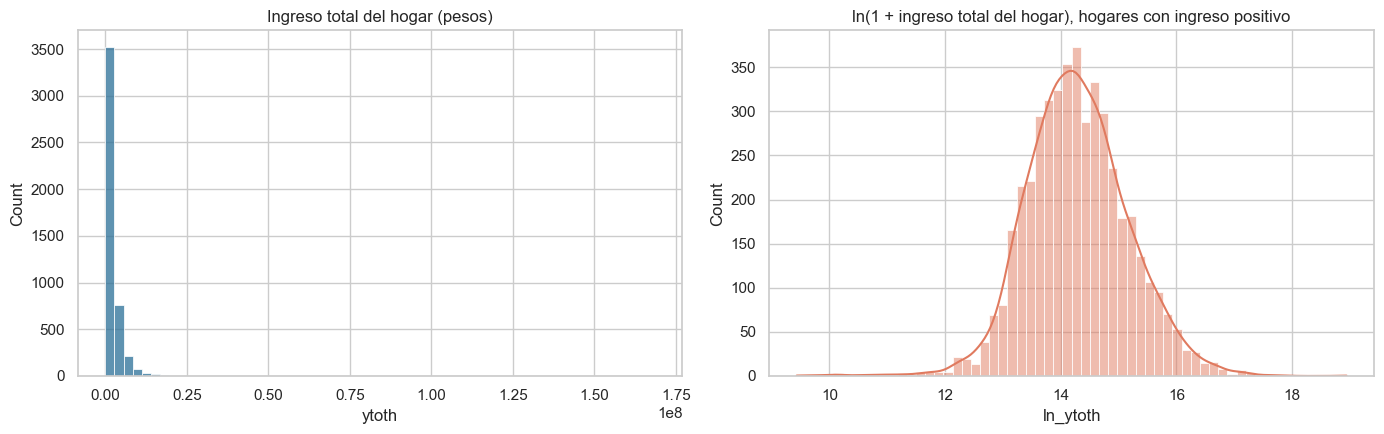

             muestral     ponderado
media   2,428,297.000 2,196,873.000
mediana 1,530,000.000 1,452,000.000

Asimetría en pesos 20.21 | en logaritmo -6.02 | en logaritmo sin ingresos cero 0.03
Hogares con ingreso cero: 26


In [14]:
df["ln_ytoth"] = np.log1p(df["ytoth"])
pos = df["ytoth"] > 0   # en escala logarítmica se grafica solo a los hogares con ingreso positivo

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(df["ytoth"], bins=60, ax=ax[0], color="#2a6f97")
ax[0].set_title("Ingreso total del hogar (pesos)")
sns.histplot(df.loc[pos, "ln_ytoth"], bins=60, kde=True, ax=ax[1], color="#e07a5f")
ax[1].set_title("ln(1 + ingreso total del hogar), hogares con ingreso positivo")
plt.tight_layout(); plt.show()

resumen_y = pd.DataFrame({
    "muestral": [df["ytoth"].mean(), df["ytoth"].median()],
    "ponderado": [media_pond(df["ytoth"], df["factor"]), mediana_pond(df["ytoth"], df["factor"])]},
    index=["media", "mediana"])
print(resumen_y.round(0).to_string())
print(f"\nAsimetría en pesos {df['ytoth'].skew():.2f} | en logaritmo {df['ln_ytoth'].skew():.2f} "
      f"| en logaritmo sin ingresos cero {df.loc[pos, 'ln_ytoth'].skew():.2f}")
print("Hogares con ingreso cero:", int((df["ytoth"] <= 0).sum()))

> **Lectura.** El ingreso total del hogar es muy asimétrico. En pesos su coeficiente de asimetría es 20,2, con una media muestral de \$2.428.297 y una mediana de \$1.530.000. Al ponderar por el factor de expansión ambas bajan (media de \$2.196.873 y mediana de \$1.452.000), lo que confirma que la muestra sobrerrepresenta a los hogares de mayores ingresos y que cualquier estadístico poblacional debe ponderarse. La transformación logarítmica deja una distribución prácticamente simétrica (asimetría de 0,03 sin considerar los hogares con ingreso cero), por lo que los modelos se estiman sobre ln(1 + ytoth). Los 26 hogares con ingreso cero no declaran ingreso laboral, de pensiones ni de subsidios, y son los mismos en las 31 réplicas. Si se incluyen, el logaritmo queda con asimetría de -6,0, porque esos hogares quedan aislados en el extremo izquierdo.

### 6.2 Covariables numéricas y transformación logarítmica

Los montos de deudas y activos tienen muchos ceros (hogares sin ese tipo de deuda o activo) y una cola larga hacia la derecha. Por eso los transformo con ln(1 + x) antes de estandarizar, lo que conserva los ceros y comprime los valores extremos.

In [15]:
asimetria = pd.DataFrame({
    "pct_ceros": [(df[c] == 0).mean() * 100 for c in NUMERICAS],
    "asimetria_original": [df[c].skew() for c in NUMERICAS],
    "asimetria_log": [np.log1p(df[c].clip(lower=0)).skew() if c in MONTOS else np.nan for c in NUMERICAS]},
    index=NUMERICAS)
asimetria.round(2)

,pct_ceros,asimetria_original,asimetria_log
ylabh,17.530,18.080,-1.590
ypenh,65.820,12.890,0.690
ysubh,67.710,8.540,0.800
ytoth,0.560,20.210,-6.020
ytotef,2.750,21.980,-4.370
hr_trabajadas_ent,36.590,0.210,NaN
d_tothip,81.970,8.360,1.690
d_nhip,56.140,7.310,0.330
d_toth,48.850,7.410,0.080
cf_dtoth,49.650,7.390,0.050


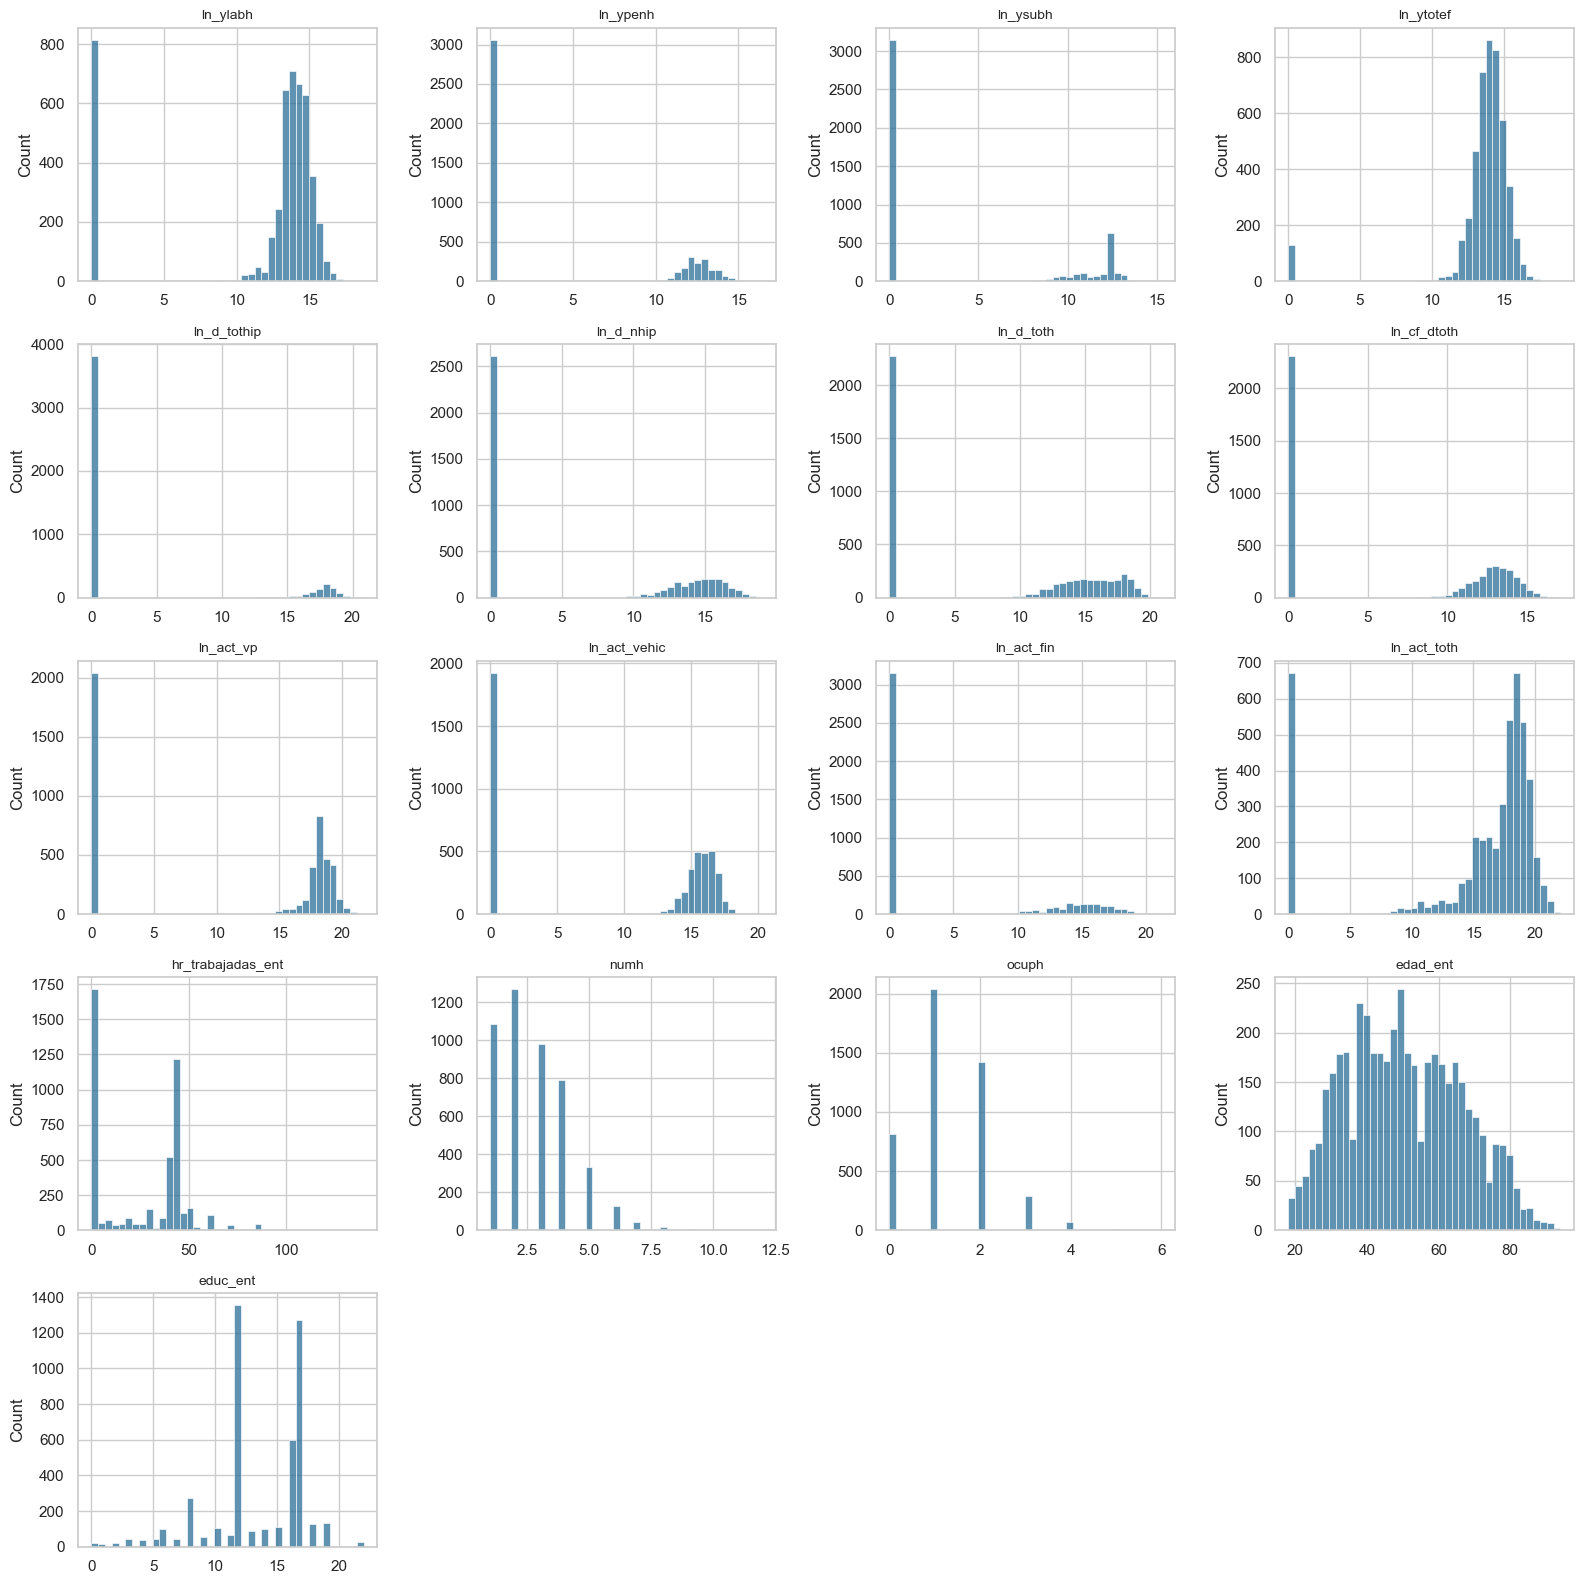

In [16]:
for c in MONTOS:
    df["ln_" + c] = np.log1p(df[c])

graficar = ["ln_" + c for c in MONTOS if c != "ytoth"] + ["hr_trabajadas_ent"] + HOGAR
filas = int(np.ceil(len(graficar) / 4))
fig, axes = plt.subplots(filas, 4, figsize=(16, 3.2 * filas))
for a, c in zip(axes.flat, graficar):
    sns.histplot(df[c], bins=40, ax=a, color="#2a6f97")
    a.set_title(c, fontsize=10); a.set_xlabel("")
for a in axes.flat[len(graficar):]:
    a.set_visible(False)
plt.tight_layout(); plt.show()

> **Lectura.** Los montos de deudas y activos se concentran en cero. En la muestra el 82% de los hogares no tiene deuda hipotecaria, el 56% no tiene deuda no hipotecaria, el 68% no declara activos financieros y el 44% no tiene valor de vivienda principal (son arrendatarios o tienen otro régimen). Las asimetrías originales van de 5 a más de 15 (activos automotrices 14,9 y financieros 15,4), y después del logaritmo quedan entre -0,3 y 1,7, lo que justifica la transformación. Los histogramas muestran distribuciones bimodales, con una barra en cero y una campana para quienes sí tienen el activo o la deuda. Las horas trabajadas son 0 para el 37% de los entrevistados, que corresponde a quienes no están ocupados.

### 6.3 Valores atípicos

Uso el criterio del rango intercuartílico (1,5 veces el IQR) sobre las variables ya transformadas. En el ejemplo NHANES los atípicos se eliminaban, pero en una encuesta financiera los hogares extremos son reales (y justamente están sobremuestreados), así que eliminarlos sesgaría la base hacia el centro de la distribución. Los mantengo y dejo que la transformación logarítmica reduzca su influencia.

Cantidad de atípicos por variable (criterio IQR)
ln_d_tothip          838
ln_ylabh             828
ln_act_toth          711
ln_ytotef            190
educ_ent             137
ln_ytoth             101
ocuph                 85
numh                  25
hr_trabajadas_ent      6
ln_d_nhip              0
ln_d_toth              0
ln_cf_dtoth            0
ln_ysubh               0
ln_act_vehic           0
ln_act_fin             0
ln_ypenh               0
edad_ent               0
ln_act_vp              0


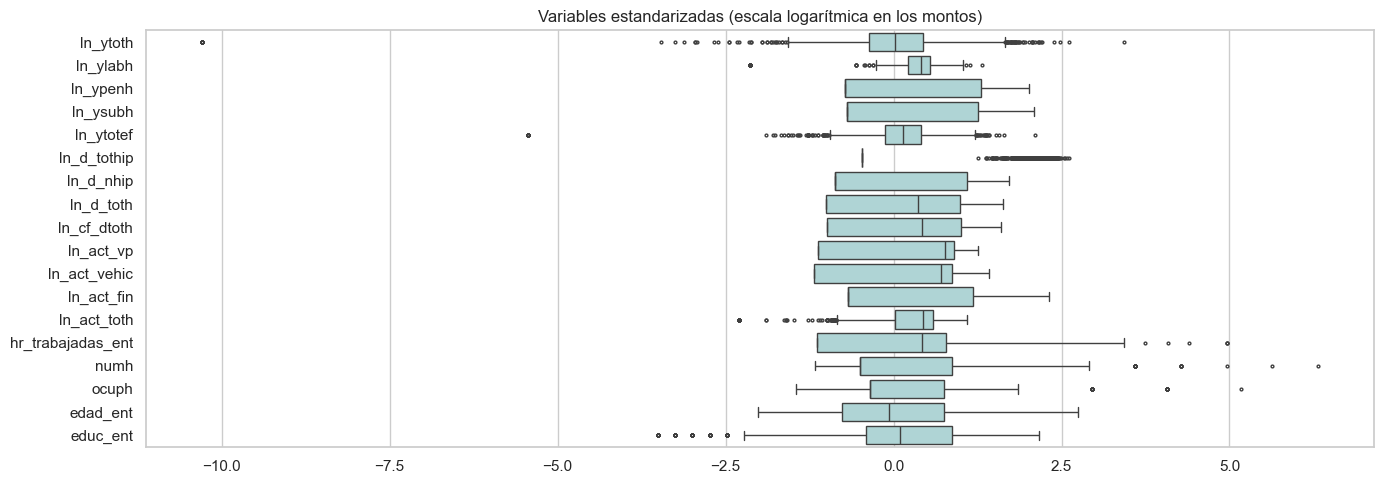

In [17]:
vars_atip = ["ln_ytoth"] + [c for c in graficar]
Q1, Q3 = df[vars_atip].quantile(.25), df[vars_atip].quantile(.75)
IQR = Q3 - Q1
atipicos = ((df[vars_atip] < Q1 - 1.5 * IQR) | (df[vars_atip] > Q3 + 1.5 * IQR)).sum()
print("Cantidad de atípicos por variable (criterio IQR)")
print(atipicos.sort_values(ascending=False).to_string())

z = (df[vars_atip] - df[vars_atip].mean()) / df[vars_atip].std()
plt.figure(figsize=(14, 5))
sns.boxplot(data=z, orient="h", fliersize=2, color="#a8dadc")
plt.title("Variables estandarizadas (escala logarítmica en los montos)")
plt.tight_layout(); plt.show()

> **Lectura.** El criterio del rango intercuartílico resulta poco adecuado para variables con muchos ceros. En la deuda hipotecaria el 82% de los hogares tiene cero, el rango intercuartílico también vale cero y los 838 hogares que sí tienen hipoteca quedan marcados como atípicos. Lo mismo ocurre con el ingreso laboral (828 casos, casi todos hogares sin ingreso laboral) y con los activos totales (711). En el logaritmo del ingreso los 101 atípicos incluyen a los 26 hogares con ingreso cero. Ninguno de estos casos es un error de registro, sino subgrupos reales de la población, así que los mantengo. La única exclusión son los hogares con ingreso cero en la parte supervisada, por la razón explicada en la sección 7.

### 6.4 Covariables categóricas y binarias

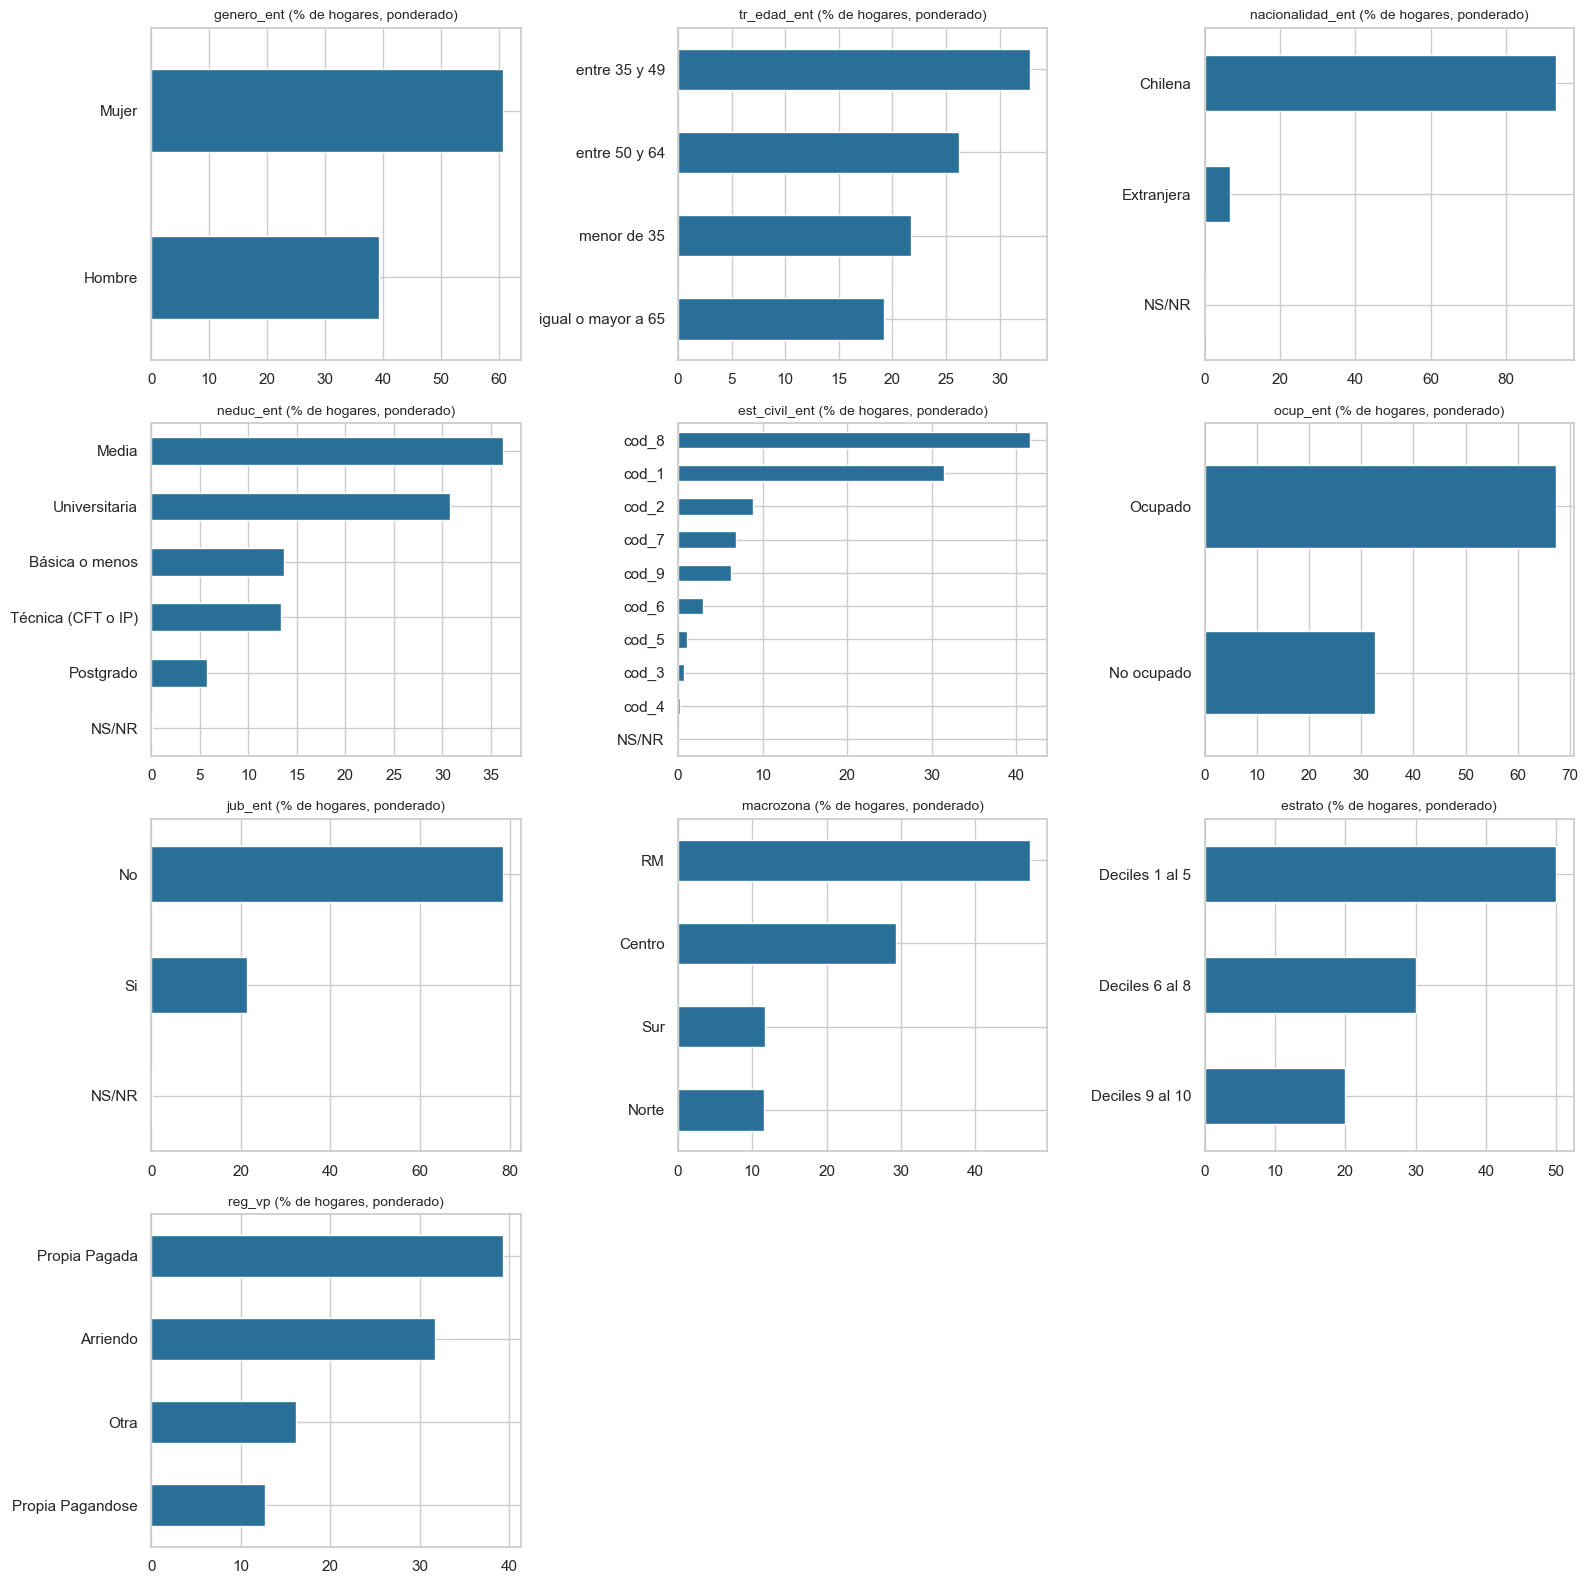

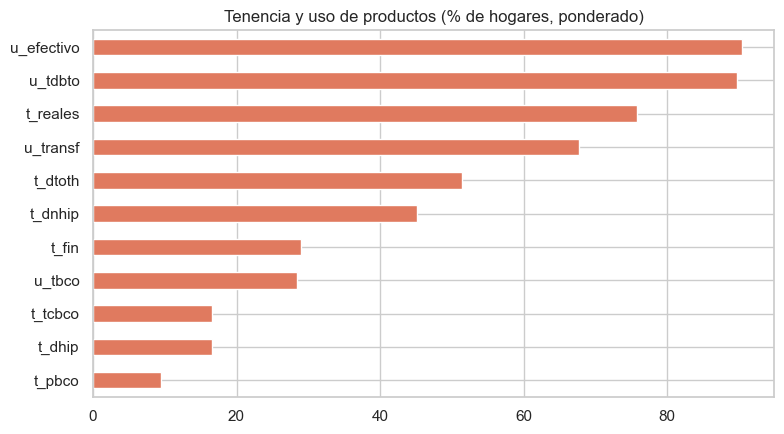

In [18]:
filas = int(np.ceil(len(CATEGORICAS) / 3))
fig, axes = plt.subplots(filas, 3, figsize=(16, 4 * filas))
for a, c in zip(axes.flat, CATEGORICAS):
    prop = df.groupby(c)["factor"].sum() / df["factor"].sum() * 100
    prop.sort_values().plot.barh(ax=a, color="#2a6f97")
    a.set_title(f"{c} (% de hogares, ponderado)", fontsize=10); a.set_ylabel("")
for a in axes.flat[len(CATEGORICAS):]:
    a.set_visible(False)
plt.tight_layout(); plt.show()

tenencia = pd.Series({c: media_pond(df[c], df["factor"]) * 100 for c in BINARIAS}).sort_values()
tenencia.plot.barh(figsize=(8, 4.5), color="#e07a5f", title="Tenencia y uso de productos (% de hogares, ponderado)")
plt.tight_layout(); plt.show()

> **Lectura.** Todos los porcentajes están ponderados, así que describen a la población de hogares. El 61% de los entrevistados son mujeres, el grupo de edad más frecuente es de 35 a 49 años (33%) y cerca del 93% es de nacionalidad chilena (los venezolanos son el 4,1%). En educación predomina la media (36%), seguida de la universitaria (31%), la básica o menos (14%), la técnica (13%) y el postgrado (6%). El 67% está ocupado y el 21% jubilado. Casi la mitad de los hogares está en la Región Metropolitana (47%). Cerca del 40% vive en vivienda propia pagada, el 31% arrienda, el 16% tiene otro régimen y el 13% está pagando su vivienda. El estrato reparte a los hogares en 50%, 30% y 20% porque se define por deciles de ingreso. En los productos financieros, el 51% de los hogares tiene alguna deuda, el 45% deuda no hipotecaria y el 16,5% deuda hipotecaria. El 76% tiene activos reales y solo el 29% activos financieros. El efectivo (90%) y la tarjeta de débito (90%) son los medios de pago más usados, seguidos de las transferencias (68%) y la tarjeta de crédito bancaria (28,5%).

### 6.5 Ingreso según las covariables categóricas

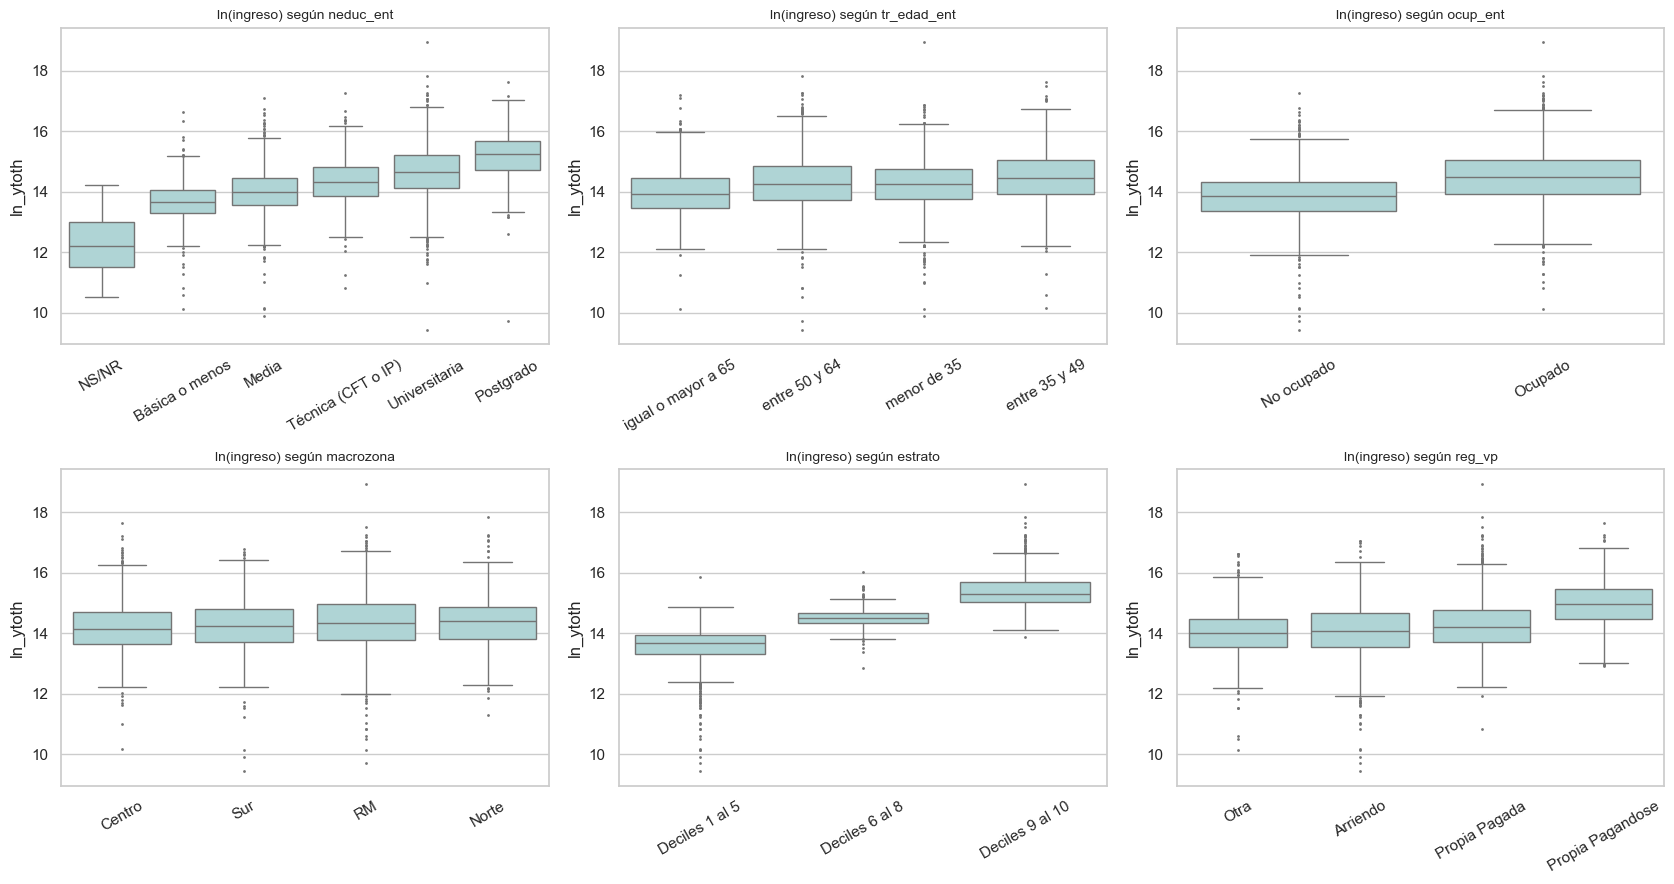

In [19]:
clave = ["neduc_ent", "tr_edad_ent", "ocup_ent", "macrozona", "estrato", "reg_vp"]
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for a, c in zip(axes.flat, clave):
    orden = df[pos].groupby(c)["ln_ytoth"].median().sort_values().index
    sns.boxplot(data=df[pos], x=c, y="ln_ytoth", order=orden, ax=a, color="#a8dadc", fliersize=1)
    a.set_title(f"ln(ingreso) según {c}", fontsize=10); a.set_xlabel("")
    a.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

In [20]:
# ANOVA de una vía para cada categórica contra el logaritmo del ingreso, como en el ejemplo NHANES
anova = {}
for c in CATEGORICAS:
    modelo = ols(f"ln_ytoth ~ C({c})", data=df[pos]).fit()
    tabla = sm.stats.anova_lm(modelo, typ=2)
    anova[c] = {"F": tabla["F"].iloc[0], "p_valor": tabla["PR(>F)"].iloc[0], "R2": modelo.rsquared}
anova = pd.DataFrame(anova).T.sort_values("R2", ascending=False)
anova["significativo_5%"] = anova["p_valor"] < 0.05
anova

,F,p_valor,R2,significativo_5%
estrato,"5,998.899",0.000,0.722,True
neduc_ent,263.061,0.000,0.222,True
reg_vp,220.672,0.000,0.125,True
ocup_ent,641.473,0.000,0.122,True
est_civil_ent,35.391,0.000,0.065,True
tr_edad_ent,69.325,0.000,0.043,True
jub_ent,93.649,0.000,0.039,True
genero_ent,76.574,0.000,0.016,True
macrozona,13.024,0.000,0.008,True
nacionalidad_ent,12.999,0.000,0.006,True


> **Lectura.** Todas las categóricas muestran diferencias significativas de ingreso al 5%, pero su poder explicativo es muy distinto. El estrato explica el 72% de la varianza del logaritmo del ingreso, lo que confirma que es una versión agrupada de la respuesta y justifica excluirlo del modelo. Entre las variables legítimas destacan la educación (22%), el régimen de vivienda (12,5%) y la situación laboral (12,2%). En cambio el género, la macrozona y la nacionalidad explican menos del 2% cada una. Los boxplots muestran que el ingreso crece de forma sostenida con el nivel educativo, desde una mediana muestral cercana a \$850 mil en básica o menos hasta unos \$4,2 millones en postgrado. En vivienda, los hogares que están pagando su casa tienen más ingreso que los que ya la pagaron. Estos últimos son en promedio mayores (56 años frente a 44, ponderado) y con muchos más jubilados (37% frente a 8%), lo que explica que su ingreso sea menor.

### 6.6 Correlaciones entre variables numéricas

ln_ytotef            0.610
ln_ylabh             0.530
ocuph                0.500
ln_act_vehic         0.490
educ_ent             0.450
ln_act_toth          0.420
ln_d_tothip          0.400
ln_act_fin           0.400
ln_d_toth            0.400
ln_cf_dtoth          0.390
hr_trabajadas_ent    0.360
numh                 0.270
ln_d_nhip            0.260
ln_act_vp            0.250
ln_ypenh            -0.020
edad_ent            -0.130
ln_ysubh            -0.230


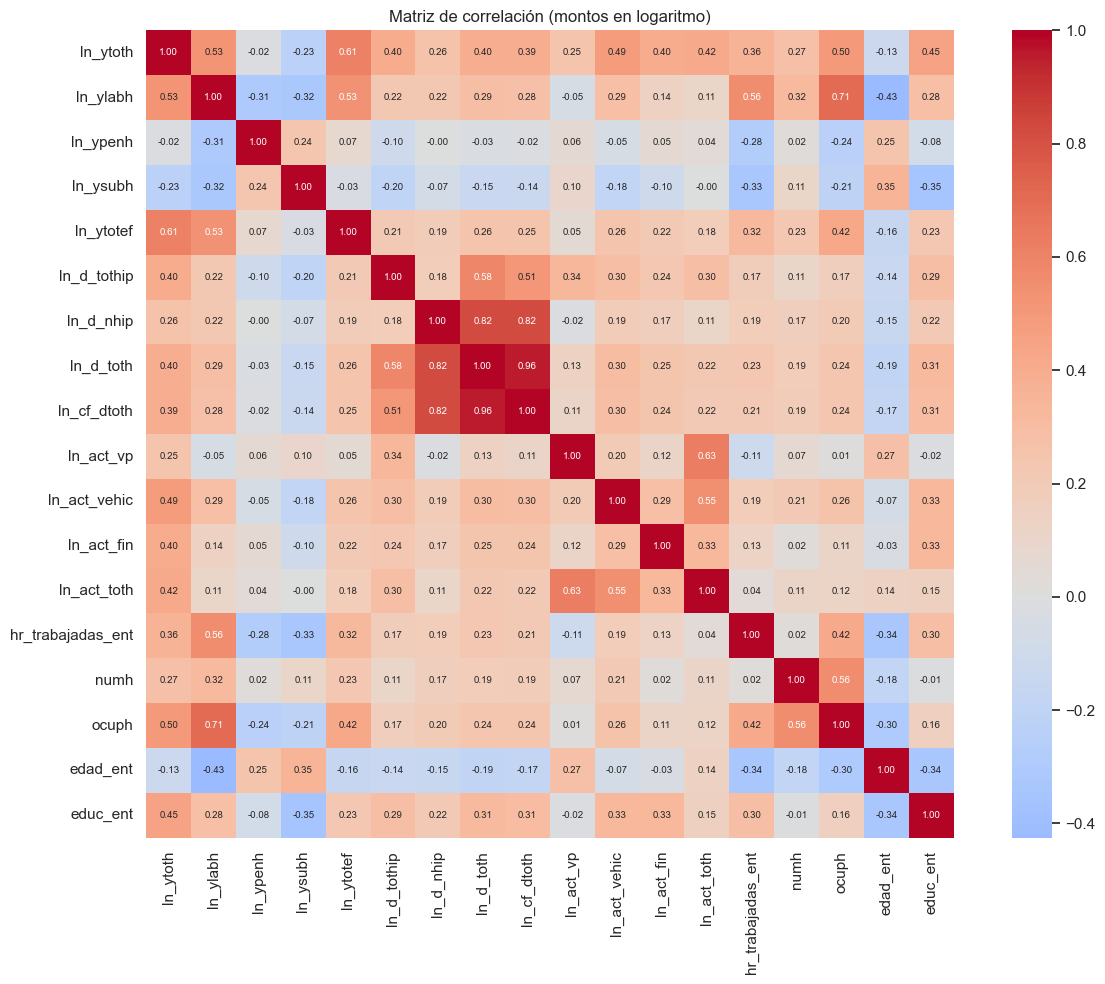

In [21]:
corr_vars = ["ln_ytoth"] + [c for c in graficar]
plt.figure(figsize=(13, 10))
print(df.loc[pos, corr_vars].corr()["ln_ytoth"].drop("ln_ytoth").sort_values(ascending=False).round(2).to_string())
sns.heatmap(df.loc[pos, corr_vars].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, square=True)
plt.title("Matriz de correlación (montos en logaritmo)")
plt.tight_layout(); plt.show()

> **Lectura.** Las variables más correlacionadas con el logaritmo del ingreso son el ingreso efectivo (0,61) y el laboral (0,53), que quedan fuera del modelo por ser partes de la respuesta. Entre los predictores, las correlaciones más altas son las del número de ocupados (0,50), el valor de los vehículos (0,49), los años de educación (0,45), la deuda hipotecaria y los activos financieros (0,40 ambos) y la carga financiera (0,39). La edad (-0,13) y los subsidios (-0,23) se asocian negativamente, lo que es coherente con que los subsidios se focalizan en los hogares de menores ingresos. Entre los predictores hay redundancias claras. La deuda total y la carga financiera tienen una correlación de 0,96, y la deuda no hipotecaria se correlaciona 0,82 con ambas, razón por la que excluyo los totales. Ninguna relación con la respuesta supera 0,5, lo que anticipa que ninguna variable por sí sola basta para predecir el ingreso.

# PARTE II. APRENDIZAJE SUPERVISADO

## 7. Planteamiento

La respuesta es **ln(1 + ytoth)**, una variable continua, por lo que el problema es de regresión. Las técnicas de balanceo de clases y la probabilidad de corte óptima no aplican, porque son propias de respuestas categóricas desbalanceadas. La asimetría de la respuesta se aborda con la transformación logarítmica, y la representatividad poblacional con el factor de expansión como `sample_weight`.

**Predictores.** Las categóricas (en indicadoras), las binarias de tenencia y uso, las horas trabajadas, los montos de deuda y activos por componente (en logaritmo) y las variables del hogar. Excluyo los totales `d_toth` y `act_toth` porque son la suma de sus componentes y serían redundantes.

**Excluidas por fuga de información.** `ylabh`, `ypenh`, `ysubh` y `ytotef` son partes o versiones del propio ingreso, y `rci_dt` y `rdi_dt` tienen el ingreso en el denominador, de modo que junto con la deuda permitirían reconstruir la respuesta. También excluyo `estrato`, porque según la metadata es el estrato de ingreso total del hogar (deciles 1 al 5, 6 al 8 y 9 al 10), es decir una versión agrupada de la propia respuesta.

**Hogares excluidos.** Los hogares con ingreso total igual a cero no reportan ingreso laboral, de pensiones ni de subsidios, y en logaritmo quedarían como valores extremos que dominarían el error. Los dejo fuera de la parte supervisada y los mantengo en la exploración y en el clúster.

**Validación.** Separo 80% para entrenamiento y 20% para prueba. Comparo los modelos con validación cruzada de 5 particiones solo sobre el entrenamiento, y reservo la prueba para evaluar una única vez al modelo elegido. Todo escalamiento ocurre dentro de un `Pipeline`, de modo que se ajusta solo con los datos de entrenamiento de cada partición.

In [22]:
FUGA = ["ylabh", "ypenh", "ysubh", "ytotef", "rci_dt", "rdi_dt", "ytoth"]
NUM_X = ["hr_trabajadas_ent", "ln_d_tothip", "ln_d_nhip", "ln_cf_dtoth",
         "ln_act_vp", "ln_act_vehic", "ln_act_fin"] + HOGAR

CAT_X = [c for c in CATEGORICAS if c != "estrato"]   # estrato son deciles de ingreso, es fuga
# Categoría de referencia de cada variable = la más frecuente en la población (no la primera alfabética,
# que podía ser NS/NR con un solo hogar y dejaba coeficientes inestables en la regresión lineal)
REFERENCIA = {c: df.groupby(c)["factor"].sum().idxmax() for c in CAT_X}
print("Categorías de referencia:", REFERENCIA)

def matriz_modelo(d, columnas=None):
    d = d[d["ytoth"] > 0]   # hogares sin ingreso de ningún tipo quedan fuera del modelo
    dummies = pd.get_dummies(d[CAT_X].astype(str), dtype=float)
    dummies = dummies.drop(columns=[f"{c}_{REFERENCIA[c]}" for c in CAT_X], errors="ignore")
    X = pd.concat([d[NUM_X + BINARIAS], dummies], axis=1)
    if columnas is not None:
        X = X.reindex(columns=columnas, fill_value=0.0)
    return X.astype(float).reset_index(drop=True), np.log1p(d["ytoth"]).values, d["factor"].values, d["id"].reset_index(drop=True)

X, y, w, ids = matriz_modelo(df)
COLUMNAS_X = X.columns
print("Hogares excluidos por ingreso cero:", int((df["ytoth"] <= 0).sum()))
X_train, X_test, y_train, y_test, w_train, w_test, id_train, id_test = train_test_split(
    X, y, w, ids, test_size=0.2, random_state=SEED)
print(f"Predictores {X.shape[1]} | entrenamiento {len(X_train)} | prueba {len(X_test)}")

Categorías de referencia: {'genero_ent': 'Mujer', 'tr_edad_ent': 'entre 35 y 49', 'nacionalidad_ent': 'Chilena', 'neduc_ent': 'Media', 'est_civil_ent': 'cod_8', 'ocup_ent': 'Ocupado', 'jub_ent': 'No', 'macrozona': 'RM', 'reg_vp': 'Propia Pagada'}
Hogares excluidos por ingreso cero: 26
Predictores 51 | entrenamiento 3698 | prueba 925


## 8. Comparación de modelos con validación cruzada

Comparo cinco modelos vistos en el curso, desde el más simple al más flexible. Uso tres indicadores, el RMSE (error típico en unidades de log ingreso), el MAE (menos sensible a errores grandes) y el R² (proporción de la varianza explicada). El criterio de selección es el **RMSE promedio de validación cruzada**.

In [23]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
modelos = {
    "Regresión lineal": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "KNN": KNeighborsRegressor(n_neighbors=10),
    "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=SEED),
    "Gradient Boosting": GradientBoostingRegressor(random_state=SEED),
}
metricas = {"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error", "r2": "r2"}

filas = []
for nombre, m in modelos.items():
    pipe = Pipeline([("escala", StandardScaler()), ("modelo", m)])
    cv = cross_validate(pipe, X_train, y_train, cv=kf, scoring=metricas, return_train_score=True)
    filas.append({"modelo": nombre,
                  "RMSE_cv": -cv["test_rmse"].mean(), "RMSE_cv_sd": cv["test_rmse"].std(),
                  "MAE_cv": -cv["test_mae"].mean(), "R2_cv": cv["test_r2"].mean(),
                  "RMSE_train": -cv["train_rmse"].mean()})
comparacion = pd.DataFrame(filas).set_index("modelo").sort_values("RMSE_cv")
comparacion

,RMSE_cv,RMSE_cv_sd,MAE_cv,R2_cv,RMSE_train
modelo,,,,,
Gradient Boosting,0.515,0.026,0.370,0.654,0.453
Random Forest,0.528,0.022,0.380,0.636,0.376
Ridge,0.544,0.027,0.391,0.612,0.534
Regresión lineal,0.544,0.027,0.392,0.612,0.533
KNN,0.628,0.019,0.465,0.484,0.565


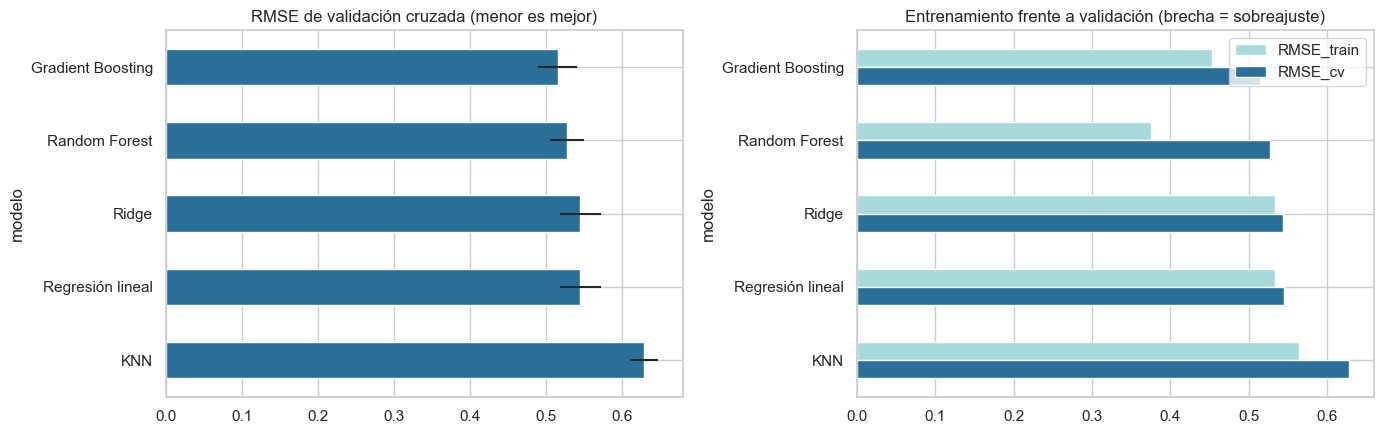

Mejor modelo según RMSE de validación cruzada: Gradient Boosting


In [24]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
comparacion["RMSE_cv"].plot.barh(xerr=comparacion["RMSE_cv_sd"], ax=ax[0], color="#2a6f97")
ax[0].set_title("RMSE de validación cruzada (menor es mejor)"); ax[0].invert_yaxis()
comparacion[["RMSE_train", "RMSE_cv"]].plot.barh(ax=ax[1], color=["#a8dadc", "#2a6f97"])
ax[1].set_title("Entrenamiento frente a validación (brecha = sobreajuste)"); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

MEJOR = comparacion.index[0]
print("Mejor modelo según RMSE de validación cruzada:", MEJOR)

> **Lectura.** Gradient Boosting obtiene el menor error de validación cruzada (RMSE 0,515 y R² 0,654), seguido de Random Forest (0,528). La regresión lineal y Ridge quedan cerca (0,544) y KNN es claramente el peor (0,628), algo esperable con 51 predictores, donde las distancias pierden capacidad de discriminar. La diferencia entre Gradient Boosting y Random Forest (0,013) es menor que la desviación estándar entre particiones (0,026), de modo que ambos rinden de forma parecida. Elijo Gradient Boosting por el criterio fijado de antemano. El gráfico de brechas muestra además que Random Forest es el que más sobreajusta (RMSE de 0,376 en entrenamiento frente a 0,528 en validación), mientras que la regresión lineal casi no sobreajusta. Que un modelo lineal quede solo 0,03 por detrás indica que buena parte de la relación con el ingreso es aproximadamente lineal en logaritmos.

## 9. Ajuste de hiperparámetros del mejor modelo

Afino los hiperparámetros del modelo elegido con `GridSearchCV`, usando las mismas 5 particiones y el mismo criterio (RMSE).

In [25]:
grillas = {
    "Regresión lineal": {},
    "Ridge": {"modelo__alpha": [0.01, 0.1, 1, 10, 100]},
    "KNN": {"modelo__n_neighbors": [5, 10, 20, 40], "modelo__weights": ["uniform", "distance"]},
    "Random Forest": {"modelo__n_estimators": [300], "modelo__max_depth": [None, 10, 20],
                      "modelo__min_samples_leaf": [1, 5, 10], "modelo__max_features": ["sqrt", 0.5]},
    "Gradient Boosting": {"modelo__n_estimators": [200, 400], "modelo__learning_rate": [0.03, 0.1],
                          "modelo__max_depth": [2, 3, 4]},
}
busqueda = GridSearchCV(Pipeline([("escala", StandardScaler()), ("modelo", modelos[MEJOR])]),
                        grillas[MEJOR] or {"modelo__fit_intercept": [True]},
                        cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1)
busqueda.fit(X_train, y_train)
print("Mejores hiperparámetros:", busqueda.best_params_)
print(f"RMSE de validación cruzada {-busqueda.best_score_:.4f} (antes {comparacion.loc[MEJOR, 'RMSE_cv']:.4f})")
modelo_final = busqueda.best_estimator_

Mejores hiperparámetros: {'modelo__learning_rate': 0.1, 'modelo__max_depth': 2, 'modelo__n_estimators': 400}
RMSE de validación cruzada 0.5132 (antes 0.5146)


## 10. Evaluación en el conjunto de prueba

Evalúo una sola vez el modelo final en el 20% reservado. Además de las métricas en logaritmo reporto el error en pesos, volviendo a la escala original. Como el error en logaritmo equivale aproximadamente a un error porcentual, informo la mediana del error porcentual absoluto.

RMSE (log)                             0.551
MAE (log)                              0.392
R2 (log)                               0.625
R2 ponderado (log)                     0.622
Mediana error % absoluto              29.086
Mediana error absoluto (pesos)   430,220.580


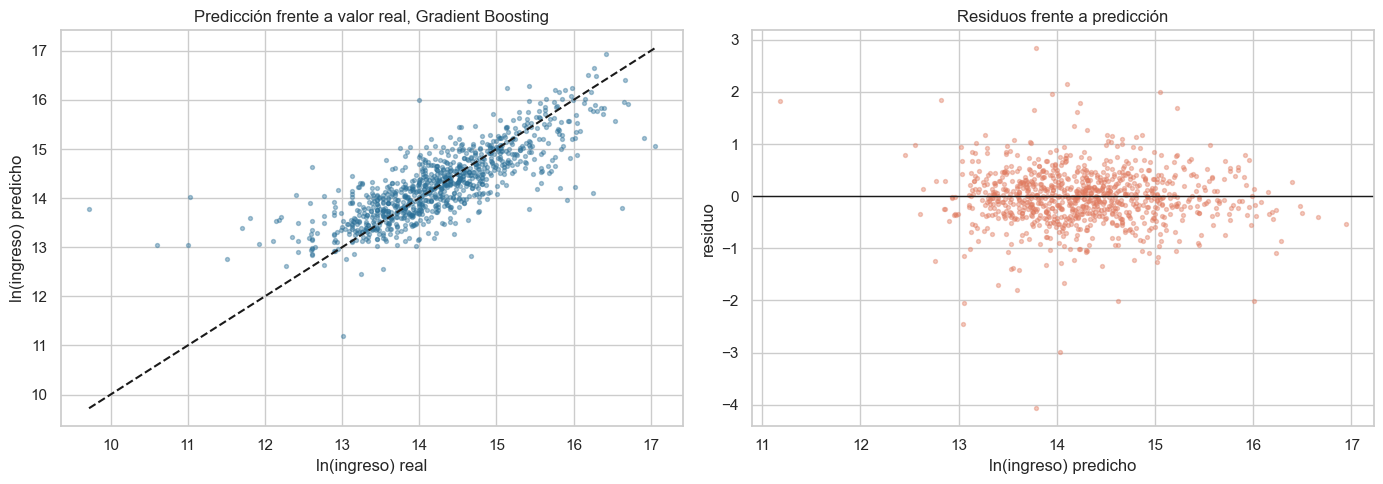

In [26]:
pred = modelo_final.predict(X_test)
ing_real, ing_pred = np.expm1(y_test), np.expm1(pred)
err_pct = np.abs(ing_pred - ing_real) / np.maximum(ing_real, 1) * 100

evaluacion = pd.Series({
    "RMSE (log)": rmse(y_test, pred),
    "MAE (log)": mean_absolute_error(y_test, pred),
    "R2 (log)": r2_score(y_test, pred),
    "R2 ponderado (log)": r2_score(y_test, pred, sample_weight=w_test),
    "Mediana error % absoluto": np.median(err_pct),
    "Mediana error absoluto (pesos)": np.median(np.abs(ing_pred - ing_real)),
}, name=MEJOR)
print(evaluacion.round(3).to_string())

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(y_test, pred, s=8, alpha=.4, color="#2a6f97")
lim = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
ax[0].plot(lim, lim, "k--", lw=1.5)
ax[0].set(title=f"Predicción frente a valor real, {MEJOR}", xlabel="ln(ingreso) real", ylabel="ln(ingreso) predicho")
residuos = y_test - pred
ax[1].scatter(pred, residuos, s=8, alpha=.4, color="#e07a5f"); ax[1].axhline(0, color="k", lw=1)
ax[1].set(title="Residuos frente a predicción", xlabel="ln(ingreso) predicho", ylabel="residuo")
plt.tight_layout(); plt.show()

> **Lectura.** El modelo final (Gradient Boosting con 400 árboles de profundidad 2 y tasa de aprendizaje 0,1) obtiene en prueba un RMSE de 0,551, un MAE de 0,392 y un R² de 0,625, muy cerca de lo estimado por validación cruzada, lo que indica que no hay sobreajuste. En pesos, la mediana del error absoluto es de unos \$430 mil y la mediana del error porcentual es 29%. El gráfico de predicción frente a valor real muestra el patrón típico de regresión hacia la media, donde el modelo sobreestima a los hogares de ingresos más bajos y subestima a los más altos. Los residuos se reparten sin una forma clara alrededor de cero, con algunos errores grandes en ingresos bajos que corresponden a hogares cuyo perfil patrimonial no calza con lo poco que declaran ganar.

### 10.1 Uso del factor de expansión

Reentreno el mismo modelo pasando el factor de expansión como `sample_weight`, para que cada hogar pese según cuántos hogares de la población representa, y comparo las métricas ponderadas en prueba.

In [27]:
modelo_pond = clone(modelo_final)
modelo_pond.fit(X_train, y_train, modelo__sample_weight=w_train)
pred_pond = modelo_pond.predict(X_test)

pd.DataFrame({
    "sin ponderar": [rmse(y_test, pred, w_test), r2_score(y_test, pred, sample_weight=w_test)],
    "ponderado": [rmse(y_test, pred_pond, w_test), r2_score(y_test, pred_pond, sample_weight=w_test)]},
    index=["RMSE ponderado en prueba", "R2 ponderado en prueba"])

,sin ponderar,ponderado
RMSE ponderado en prueba,0.510,0.511
R2 ponderado en prueba,0.622,0.620


> **Lectura.** Entrenar con el factor de expansión no mejora el ajuste. El RMSE ponderado en prueba es prácticamente igual (0,510 sin ponderar y 0,511 ponderado) y el R² también (0,622 y 0,620). Como el objetivo del modelo es predecir el ingreso de cada hogar y no estimar un parámetro poblacional, me quedo con el modelo sin ponderar, y reservo el factor de expansión para los estadísticos descriptivos.

### 10.2 Estabilidad entre réplicas de imputación

Para verificar que el resultado no depende de la réplica elegida, repito el entrenamiento y la evaluación del modelo final en cada réplica de imputación, manteniendo exactamente los mismos hogares en entrenamiento y en prueba. Esto se aproxima a la recomendación de promediar los resultados sobre las imputaciones.

In [28]:
estabilidad = []
for r in REPLICAS:
    d = limpiar(replica(r), replica(r, etiquetada=True))
    for c in MONTOS:
        d["ln_" + c] = np.log1p(d[c])
    Xr, yr, _, idr = matriz_modelo(d, COLUMNAS_X)
    ent, pru = idr.isin(id_train).values, idr.isin(id_test).values
    m = clone(modelo_final).fit(Xr[ent], yr[ent])
    p = m.predict(Xr[pru])
    estabilidad.append({"imp": r, "RMSE": rmse(yr[pru], p), "R2": r2_score(yr[pru], p)})
estabilidad = pd.DataFrame(estabilidad).set_index("imp")
print(estabilidad.round(4).to_string())
print(f"\nPromedio RMSE {estabilidad['RMSE'].mean():.4f} (de {estabilidad['RMSE'].std():.4f}) | "
      f"promedio R2 {estabilidad['R2'].mean():.4f} (de {estabilidad['R2'].std():.4f})")

        RMSE    R2
imp               
1.000  0.551 0.625
2.000  0.538 0.640
3.000  0.528 0.645
4.000  0.537 0.633
5.000  0.537 0.637
6.000  0.541 0.632
7.000  0.539 0.632
8.000  0.546 0.626
9.000  0.530 0.641
10.000 0.535 0.640
11.000 0.535 0.638
12.000 0.540 0.640
13.000 0.538 0.632
14.000 0.540 0.639
15.000 0.532 0.644
16.000 0.533 0.633
17.000 0.532 0.638
18.000 0.544 0.631
19.000 0.542 0.636
20.000 0.528 0.646
21.000 0.542 0.627
22.000 0.524 0.649
23.000 0.539 0.633
24.000 0.536 0.632
25.000 0.530 0.647
26.000 0.532 0.643
27.000 0.538 0.631
28.000 0.532 0.640
29.000 0.535 0.638
30.000 0.541 0.632

Promedio RMSE 0.5366 (de 0.0058) | promedio R2 0.6366 (de 0.0063)


> **Lectura.** Los resultados son muy estables entre réplicas. En las 30 réplicas imputadas el RMSE promedio es 0,537 (desviación estándar de 0,006) y el R² promedio es 0,637 (desviación de 0,006), con rangos de 0,524 a 0,551 y de 0,625 a 0,649. La réplica 1, que es la usada en el resto del análisis, resulta ser la de peor desempeño de las 30, así que las métricas reportadas son conservadoras. La conclusión del modelo no depende de qué imputación se elija.

## 11. Variables más influyentes

Uso la importancia por permutación sobre el conjunto de prueba, que mide cuánto empeora el error cuando se desordena al azar cada predictor. Tiene la ventaja de aplicarse a cualquier modelo. Como complemento ajusto una regresión lineal por mínimos cuadrados con errores robustos, cuyos coeficientes sobre el logaritmo del ingreso se leen aproximadamente como variaciones porcentuales.

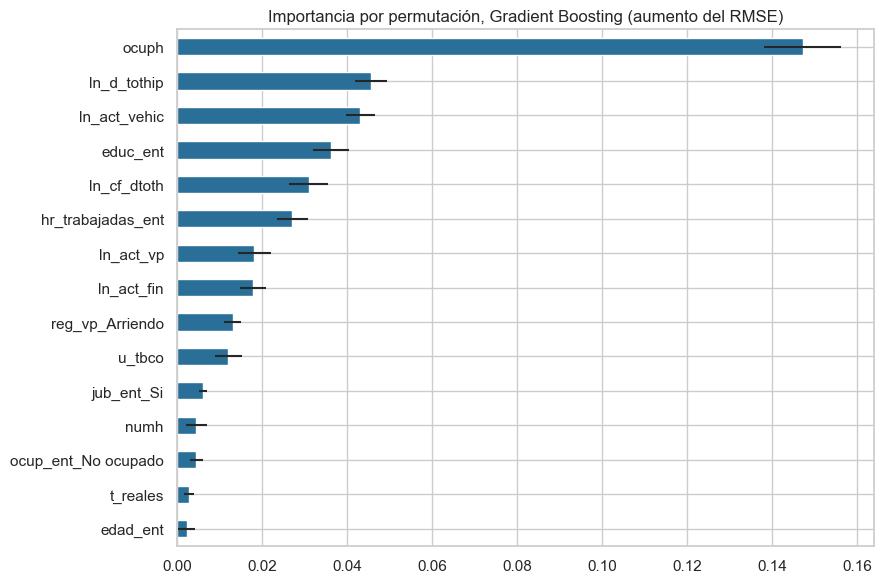

,importancia,sd
ocuph,0.147,0.009
ln_d_tothip,0.046,0.004
ln_act_vehic,0.043,0.003
educ_ent,0.036,0.004
ln_cf_dtoth,0.031,0.005
hr_trabajadas_ent,0.027,0.004
ln_act_vp,0.018,0.004
ln_act_fin,0.018,0.003
reg_vp_Arriendo,0.013,0.002
u_tbco,0.012,0.003


In [29]:
perm = permutation_importance(modelo_final, X_test, y_test, n_repeats=10, random_state=SEED,
                              scoring="neg_root_mean_squared_error", n_jobs=-1)
importancia = (pd.DataFrame({"importancia": perm.importances_mean, "sd": perm.importances_std}, index=COLUMNAS_X)
                 .sort_values("importancia", ascending=False))
top = importancia.head(15)[::-1]
top["importancia"].plot.barh(xerr=top["sd"], figsize=(9, 6), color="#2a6f97")
plt.title(f"Importancia por permutación, {MEJOR} (aumento del RMSE)")
plt.tight_layout(); plt.show()
importancia.head(15)

In [30]:
# Las tenencias de deuda y activos (t_*) son redundantes con sus montos en logaritmo (monto > 0),
# así que se quitan de la regresión lineal para que los coeficientes se puedan interpretar.
X_ols = X_train.drop(columns=["t_dhip", "t_dnhip", "t_dtoth", "t_reales", "t_fin"])
ols_mod = sm.OLS(y_train, sm.add_constant(X_ols)).fit(cov_type="HC3")
coefs = pd.DataFrame({"coef": ols_mod.params, "p_valor": ols_mod.pvalues})
coefs["efecto_%"] = (np.exp(coefs["coef"]) - 1) * 100
print(f"R2 de la regresión lineal en entrenamiento {ols_mod.rsquared:.3f}")
coefs.drop("const").query("p_valor < 0.05").reindex(
    coefs.drop("const").query("p_valor < 0.05")["coef"].abs().sort_values(ascending=False).index).head(20)

R2 de la regresión lineal en entrenamiento 0.619


,coef,p_valor,efecto_%
neduc_ent_NS/NR,-1.899,0.046,-85.021
reg_vp_Otra,1.346,0.000,284.283
reg_vp_Arriendo,1.179,0.001,225.196
neduc_ent_Postgrado,0.435,0.000,54.472
ocuph,0.316,0.000,37.182
neduc_ent_Universitaria,0.242,0.000,27.422
u_tbco,0.241,0.000,27.200
reg_vp_Propia Pagandose,-0.190,0.002,-17.293
nacionalidad_ent_Extranjera,-0.180,0.001,-16.476
u_efectivo,-0.139,0.000,-12.976


> **Lectura.** El número de ocupados del hogar es por lejos el predictor más importante (su permutación aumenta el RMSE en 0,147, tres veces más que el siguiente). Le siguen la deuda hipotecaria, el valor de los vehículos, los años de educación, la carga financiera y las horas trabajadas. Es decir, el ingreso se predice sobre todo por cuántas personas trabajan en el hogar, por su capital humano y por su posición patrimonial y de endeudamiento, mientras que el género, la macrozona o la nacionalidad aportan muy poco.

La regresión lineal (R² de 0,619) permite leer magnitudes, siempre manteniendo constante el resto de las variables. Cada ocupado adicional se asocia a un ingreso 37% mayor. Frente a educación media, tener postgrado se asocia a un ingreso 54% mayor y tener universitaria a uno 27% mayor. Usar tarjeta de crédito bancaria se asocia a un 27% más, y que el entrevistado sea extranjero a un 16% menos. Frente a la Región Metropolitana, los hogares de las macrozonas Centro y Sur tienen alrededor de 7% menos de ingreso. Dos coeficientes requieren cuidado. El de arriendo (+1,18 frente a vivienda propia pagada) no significa que los arrendatarios ganen más, porque el modelo también incluye el logaritmo del valor de la vivienda, que es cero para ellos. Para un propietario con una vivienda de \$30 millones ese término suma cerca de 1,43, así que el efecto neto sigue favoreciendo a los propietarios en unos 0,25 puntos del logaritmo. El coeficiente de NS/NR en educación descansa en solo 5 hogares y no es interpretable, al igual que los códigos de estado civil, cuyas etiquetas no son confiables.

# PARTE III. APRENDIZAJE NO SUPERVISADO

## 12. Planteamiento

Agrupo a los hogares **sin usar el ingreso**. Para que la exclusión sea real dejo fuera también las componentes del ingreso y los ratios que lo contienen. Las variables de agrupamiento describen la posición financiera y demográfica del hogar, es decir los montos de deuda hipotecaria y no hipotecaria, la carga financiera, los activos (vivienda, vehículos, financieros), el tamaño del hogar, los ocupados, y la edad, escolaridad y horas trabajadas del entrevistado.

Todas son continuas, así que uso **K-medias** sobre las variables estandarizadas (los montos, en logaritmo), porque se basa en distancias euclidianas y la estandarización evita que las variables en pesos dominen. Como respaldo aplico un clúster jerárquico de Ward y mido cuánto coinciden ambas particiones. Las variables de tenencia y el ingreso se usan solo después, para describir los grupos.

In [31]:
VARS_CLUSTER = ["ln_d_tothip", "ln_d_nhip", "ln_cf_dtoth", "ln_act_vp", "ln_act_vehic", "ln_act_fin",
                "numh", "ocuph", "edad_ent", "educ_ent", "hr_trabajadas_ent"]
Xc = StandardScaler().fit_transform(df[VARS_CLUSTER])
print("Hogares", Xc.shape[0], "| variables de agrupamiento", Xc.shape[1])

Hogares 4649 | variables de agrupamiento 11


## 13. Cantidad de grupos

Evalúo de 2 a 10 grupos con cuatro criterios establecidos de antemano. El método del codo sobre la inercia, el coeficiente de silueta (mayor es mejor), el índice de Calinski-Harabasz (mayor es mejor) y el de Davies-Bouldin (menor es mejor). Elijo el k donde los criterios coinciden o, si discrepan, el que ofrece mejor silueta sin fragmentar a la población en grupos muy pequeños.

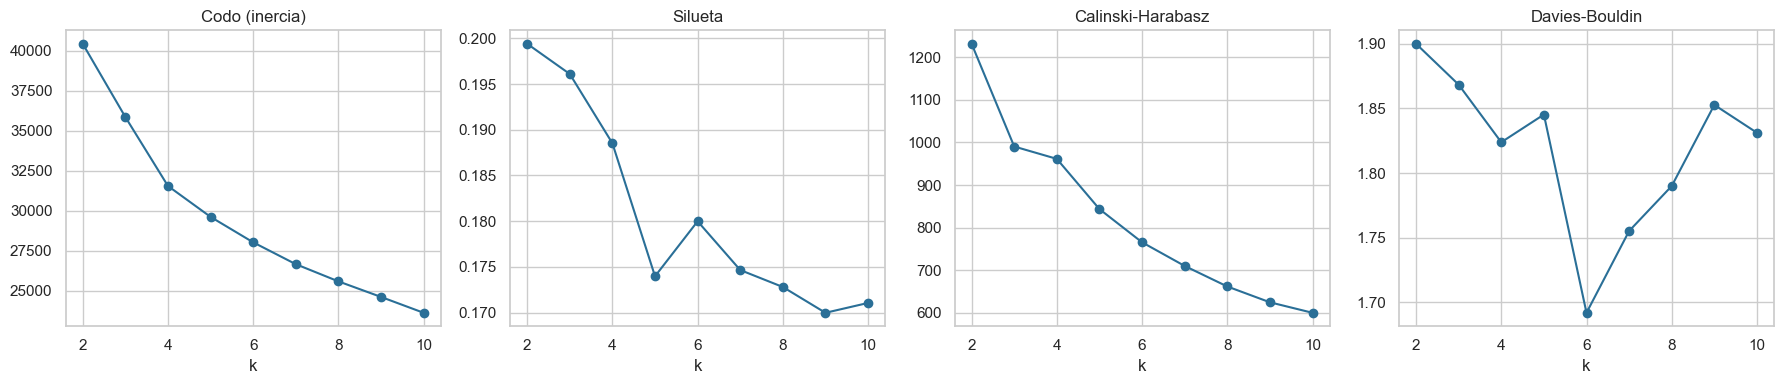

,inercia,silueta,calinski_harabasz,davies_bouldin,grupo_mas_chico_%
k,,,,,
2,"40,423.681",0.199,"1,231.814",1.900,45.752
3,"35,852.321",0.196,990.479,1.868,17.832
4,"31,548.668",0.189,961.448,1.824,17.681
5,"29,619.820",0.174,843.483,1.845,16.477
6,"28,031.416",0.180,765.488,1.692,9.142
7,"26,667.747",0.175,709.945,1.755,10.110
8,"25,594.558",0.173,661.702,1.790,7.980
9,"24,623.210",0.170,624.581,1.853,8.346
10,"23,633.467",0.171,599.894,1.831,6.216


In [32]:
rango_k = range(2, 11)
eval_k = []
for k in rango_k:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(Xc)
    eval_k.append({"k": k, "inercia": km.inertia_,
                   "silueta": silhouette_score(Xc, km.labels_, sample_size=min(4000, len(Xc)), random_state=SEED),
                   "calinski_harabasz": calinski_harabasz_score(Xc, km.labels_),
                   "davies_bouldin": davies_bouldin_score(Xc, km.labels_),
                   "grupo_mas_chico_%": np.bincount(km.labels_).min() / len(Xc) * 100})
eval_k = pd.DataFrame(eval_k).set_index("k")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for a, (c, t) in zip(axes, [("inercia", "Codo (inercia)"), ("silueta", "Silueta"),
                            ("calinski_harabasz", "Calinski-Harabasz"), ("davies_bouldin", "Davies-Bouldin")]):
    a.plot(eval_k.index, eval_k[c], marker="o", color="#2a6f97"); a.set_title(t); a.set_xlabel("k")
plt.tight_layout(); plt.show()
eval_k

In [33]:
# k elegido. Por defecto, el de mayor silueta entre los que no dejan grupos de menos del 5% de los hogares.
# Si la lectura conjunta de los cuatro criterios sugiere otro valor, se fija aquí a mano.
K_OPT = int(eval_k.query("`grupo_mas_chico_%` >= 5")["silueta"].idxmax())
print("Cantidad de grupos elegida:", K_OPT)

Cantidad de grupos elegida: 2


> **Lectura.** Los criterios no apuntan todos al mismo número. La silueta es máxima con 2 grupos (0,199), casi empatada con 3 (0,196). Calinski-Harabasz también favorece 2 grupos (1.232), mientras que Davies-Bouldin mejora hasta 6 grupos (1,69) y el codo no muestra un quiebre marcado. Según la regla definida, elijo 2 grupos, que además dejan al grupo más chico con el 46% de los hogares. Conviene notar que todas las siluetas están por debajo de 0,2, lo que indica una estructura débil con grupos que se traslapan. Los hogares se distribuyen más como un continuo que como tipos separados, y el agrupamiento corta ese continuo en su eje principal.

## 14. Agrupamiento final y visualización

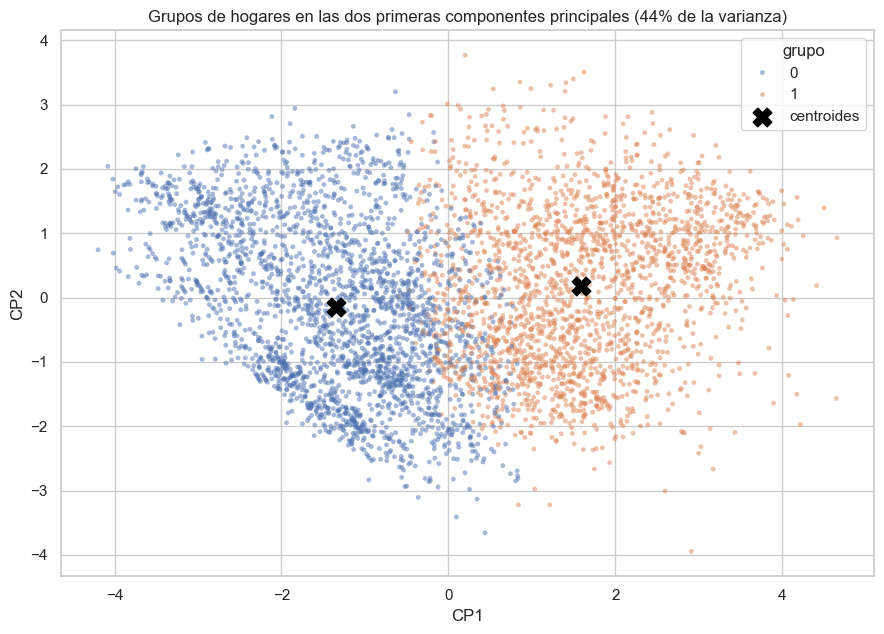

In [34]:
km = KMeans(n_clusters=K_OPT, n_init=20, random_state=SEED).fit(Xc)
df["cluster"] = km.labels_

pca = PCA(n_components=2, random_state=SEED)
Z = pca.fit_transform(Xc)
plt.figure(figsize=(9, 6.5))
sns.scatterplot(x=Z[:, 0], y=Z[:, 1], hue=df["cluster"], palette="deep", s=12, alpha=.5, linewidth=0)
centros = pca.transform(km.cluster_centers_)
plt.scatter(centros[:, 0], centros[:, 1], c="black", marker="X", s=180, label="centroides")
plt.title(f"Grupos de hogares en las dos primeras componentes principales "
          f"({pca.explained_variance_ratio_.sum() * 100:.0f}% de la varianza)")
plt.xlabel("CP1"); plt.ylabel("CP2"); plt.legend(title="grupo")
plt.tight_layout(); plt.show()

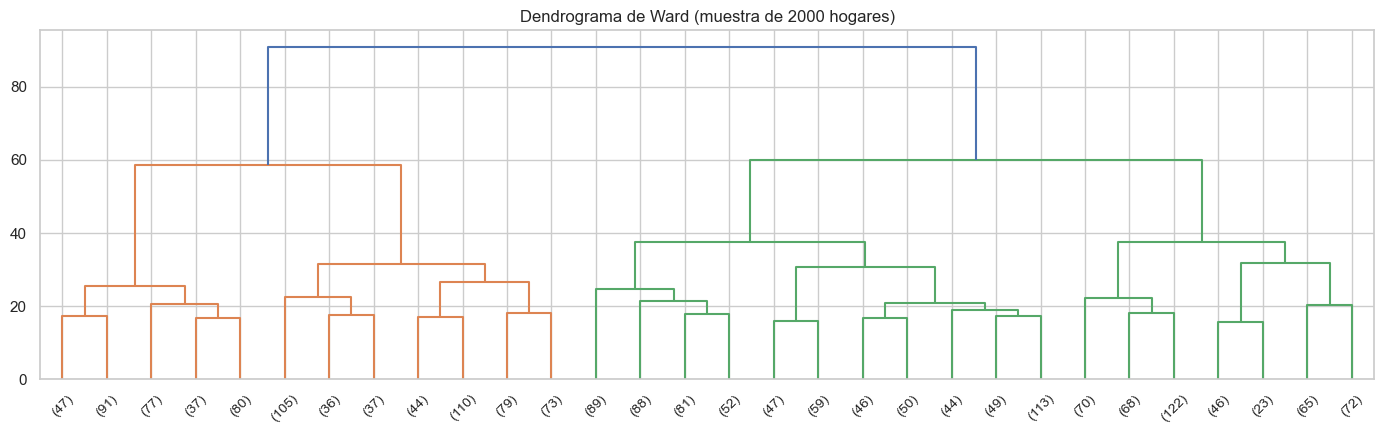

Coincidencia entre K-medias y Ward (índice de Rand ajustado) 0.757


In [35]:
# Respaldo con clúster jerárquico de Ward sobre una muestra (el dendrograma completo es ilegible)
rng = np.random.default_rng(SEED)
muestra = rng.choice(len(Xc), size=min(2000, len(Xc)), replace=False)
enlace = linkage(Xc[muestra], method="ward")

plt.figure(figsize=(14, 4.5))
dendrogram(enlace, truncate_mode="lastp", p=30, color_threshold=enlace[-(K_OPT - 1), 2])
plt.title(f"Dendrograma de Ward (muestra de {len(muestra)} hogares)")
plt.tight_layout(); plt.show()

ward = fcluster(enlace, K_OPT, criterion="maxclust")
print(f"Coincidencia entre K-medias y Ward (índice de Rand ajustado) "
      f"{adjusted_rand_score(df['cluster'].values[muestra], ward):.3f}")

## 15. Descripción de los grupos

Describo cada grupo con estadísticos **ponderados** por el factor de expansión, para que representen a la población y no a la muestra. Para los montos uso la mediana (la media se distorsiona con los extremos) y para las tenencias el porcentaje de hogares.

In [36]:
def perfil(g):
    f = g["factor"]
    fila = {"hogares_muestra": len(g), "% hogares (pob.)": f.sum() / df["factor"].sum() * 100}
    for c in ["d_tothip", "d_nhip", "cf_dtoth", "act_vp", "act_vehic", "act_fin"]:
        fila["mediana " + c] = mediana_pond(g[c], f)
    for c in ["numh", "ocuph", "edad_ent", "educ_ent", "hr_trabajadas_ent"]:
        fila["media " + c] = media_pond(g[c], f)
    for c in ["t_dhip", "t_dnhip", "t_tcbco", "t_reales", "t_fin", "u_transf"]:
        fila["% " + c] = media_pond(g[c], f) * 100
    return pd.Series(fila)

perfiles = df.groupby("cluster").apply(perfil).T
perfiles.style.format("{:,.1f}")

cluster,0,1
hogares_muestra,"2,523.0","2,126.0"
% hogares (pob.),56.3,43.7
mediana d_tothip,0.0,0.0
mediana d_nhip,0.0,"1,913,082.0"
mediana cf_dtoth,0.0,"500,000.0"
mediana act_vp,0.0,"40,000,000.0"
mediana act_vehic,0.0,"6,000,000.0"
mediana act_fin,0.0,0.0
media numh,2.4,3.0
media ocuph,1.1,1.6


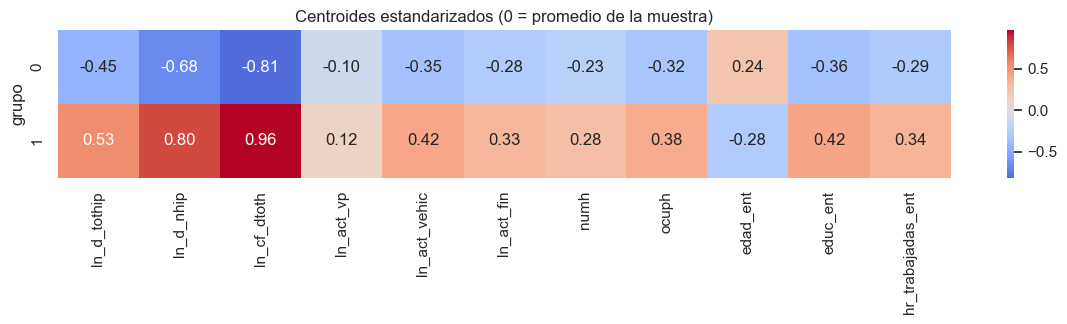

In [37]:
# Mapa de calor de los centroides estandarizados, para ver qué distingue a cada grupo
centroides = pd.DataFrame(km.cluster_centers_, columns=VARS_CLUSTER)
plt.figure(figsize=(12, 0.7 * K_OPT + 2))
sns.heatmap(centroides, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Centroides estandarizados (0 = promedio de la muestra)"); plt.ylabel("grupo")
plt.tight_layout(); plt.show()

> **Lectura y nombre de cada grupo.** El agrupamiento separa a los hogares según su participación en el sistema financiero, y los centroides muestran que las variables que más los distinguen son la carga financiera y la deuda no hipotecaria.

**Grupo 0. Hogares fuera del crédito** (56% de los hogares). Casi no tienen deuda (0,8% con hipoteca y 14% con deuda no hipotecaria) y la mediana de su vivienda, vehículos y activos financieros es cero, aunque el 68% tiene algún activo real. Son hogares algo más chicos (2,4 personas) y con menos ocupados (1,1). Sus entrevistados son mayores (52 años en promedio), tienen menos escolaridad (12,2 años) y trabajan menos horas (21 por semana, contando como cero a quienes no trabajan). Solo la mitad usa transferencias electrónicas.

**Grupo 1. Hogares bancarizados y endeudados** (44% de los hogares). El 85% tiene deuda no hipotecaria, el 37% hipoteca y el 36% deuda en tarjetas bancarias, con una carga financiera mediana de \$500 mil mensuales. También concentran el patrimonio, con una vivienda de \$40 millones y vehículos por \$6 millones en mediana, y el 45% tiene activos financieros. Son hogares más grandes (3 personas) y con más ocupados (1,6), con entrevistados más jóvenes (44 años), más escolaridad (15 años) y más horas de trabajo (34). El 85% usa transferencias.

El clúster jerárquico de Ward llega a una partición muy parecida (índice de Rand ajustado de 0,76), lo que respalda que estos dos grupos no dependen del algoritmo elegido.

## 16. Contraste de los grupos con el ingreso

Recién ahora incorporo el ingreso, que no participó en el agrupamiento. Si los grupos se ordenan claramente por ingreso, la posición patrimonial y demográfica basta para reconstruir la estratificación económica. Los hogares que caen en un grupo que no corresponde a su quintil de ingreso son la información no evidente que interesa comentar.

         mediana ingreso (pond.)  media ingreso (pond.)
cluster                                                
0                  1,090,000.000          1,458,965.000
1                  2,116,667.000          3,146,818.000


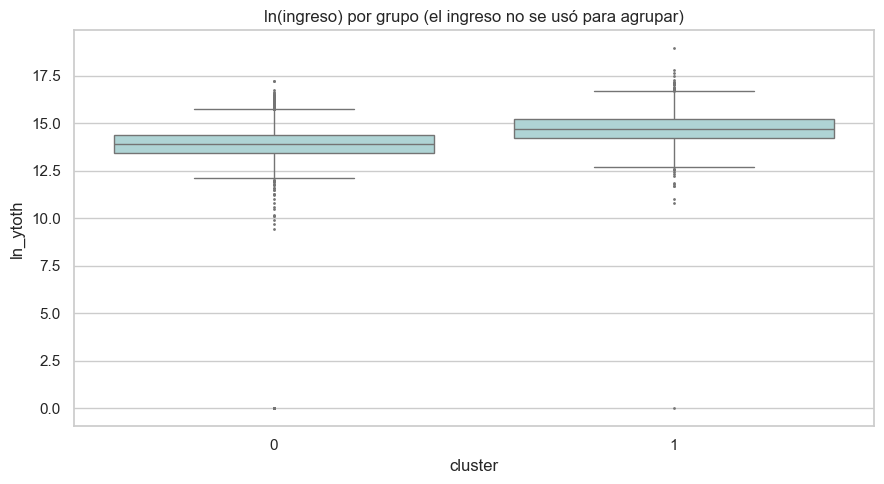

In [38]:
contraste = df.groupby("cluster").apply(lambda g: pd.Series({
    "mediana ingreso (pond.)": mediana_pond(g["ytoth"], g["factor"]),
    "media ingreso (pond.)": media_pond(g["ytoth"], g["factor"])}))
print(contraste.round(0).to_string())

orden = contraste["mediana ingreso (pond.)"].sort_values().index
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="cluster", y="ln_ytoth", order=orden, color="#a8dadc", fliersize=1)
plt.title("ln(ingreso) por grupo (el ingreso no se usó para agrupar)")
plt.tight_layout(); plt.show()

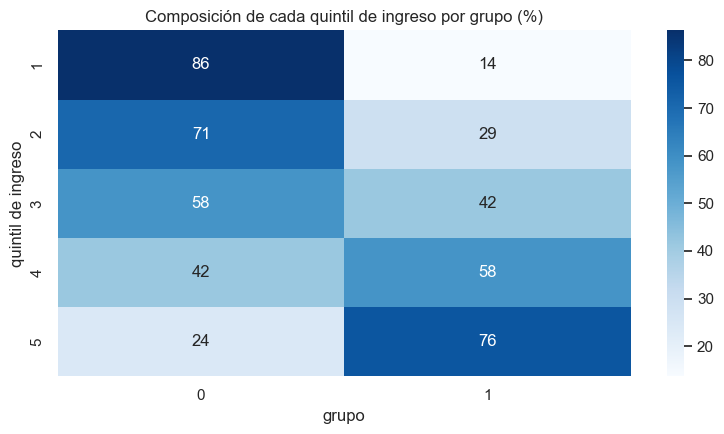

In [39]:
# Quintiles de ingreso ponderados y su cruce con los grupos (% de hogares de cada quintil, ponderado)
orden_y = np.argsort(df["ytoth"].values)
acum = np.cumsum(df["factor"].values[orden_y]) / df["factor"].sum()
quintil = np.empty(len(df), int)
quintil[orden_y] = np.minimum((acum * 5).astype(int), 4) + 1
df["quintil_ingreso"] = quintil

cruce = pd.crosstab(df["quintil_ingreso"], df["cluster"], values=df["factor"], aggfunc="sum", normalize="index") * 100
plt.figure(figsize=(8, 4.5))
sns.heatmap(cruce[orden], annot=True, fmt=".0f", cmap="Blues")
plt.title("Composición de cada quintil de ingreso por grupo (%)")
plt.xlabel("grupo"); plt.ylabel("quintil de ingreso")
plt.tight_layout(); plt.show()

### 16.1 Hogares que no calzan con su nivel de ingreso

Los casos más interesantes son los que el agrupamiento ubica lejos de lo que su ingreso haría esperar, es decir los hogares de menores ingresos que quedan en el grupo endeudado y los de mayores ingresos que quedan en el grupo sin deuda. Para ellos reviso la carga financiera, medida con la razón entre el pago mensual de deudas y el ingreso mensual (`rci_dt`), que no participó en el agrupamiento.

In [40]:
# Grupo endeudado = el de mayor proporción de hogares con deuda
endeudado = int(df.groupby("cluster").apply(lambda g: media_pond(g["t_dtoth"], g["factor"])).idxmax())

def carga(g):
    f = g["factor"]
    con_deuda = g["t_dtoth"] == 1
    r, fr = g.loc[con_deuda, "rci_dt"], f[con_deuda]
    ok = r.notna()
    return pd.Series({
        "% de la población": f.sum() / df["factor"].sum() * 100,
        "mediana ingreso": mediana_pond(g["ytoth"], f),
        "% con deuda": media_pond(g["t_dtoth"], f) * 100,
        "mediana carga financiera / ingreso (%)": mediana_pond(r[ok], fr[ok]) * 100 if ok.any() else np.nan,
        "% que destina más de la mitad del ingreso a deudas": media_pond((r[ok] > 0.5).astype(float), fr[ok]) * 100 if ok.any() else np.nan,
    })

segmentos = {
    "Quintil 1 en el grupo endeudado": df[(df["quintil_ingreso"] == 1) & (df["cluster"] == endeudado)],
    "Quintil 1 en el otro grupo": df[(df["quintil_ingreso"] == 1) & (df["cluster"] != endeudado)],
    "Quintil 5 en el grupo endeudado": df[(df["quintil_ingreso"] == 5) & (df["cluster"] == endeudado)],
    "Quintil 5 en el otro grupo": df[(df["quintil_ingreso"] == 5) & (df["cluster"] != endeudado)],
    "Todos los hogares con deuda": df[df["t_dtoth"] == 1],
}
print("Grupo endeudado:", endeudado, "| carga financiera calculada solo entre hogares con deuda")
pd.DataFrame({k: carga(v) for k, v in segmentos.items()}).T.round(1)

Grupo endeudado: 1 | carga financiera calculada solo entre hogares con deuda


,% de la población,mediana ingreso,% con deuda,mediana carga financiera / ingreso (%),% que destina más de la mitad del ingreso a deudas
Quintil 1 en el grupo endeudado,2.700,"637,640.000",100.000,54.000,52.400
Quintil 1 en el otro grupo,17.300,"549,999.400",17.900,10.100,24.000
Quintil 5 en el grupo endeudado,15.200,"4,410,790.900",97.700,23.000,23.200
Quintil 5 en el otro grupo,4.900,"4,086,073.400",6.200,21.400,0.000
Todos los hogares con deuda,51.400,"1,870,000.000",100.000,24.300,25.700


> **Lectura.** Aunque el ingreso no participó en el agrupamiento, los grupos se ordenan claramente según él. La mediana ponderada del ingreso es de \$1.090.000 en el grupo 0 y de \$2.116.667 en el grupo 1, casi el doble. El cruce con los quintiles es monótono. El grupo sin deuda reúne al 86% de los hogares del primer quintil y va bajando hasta el 24% del quinto, mientras que el grupo endeudado pasa del 14% al 76%. La posición patrimonial y de endeudamiento reconstruye entonces buena parte de la estratificación por ingreso.

La información menos evidente está en los hogares que no calzan. Los hogares del primer quintil que quedan en el grupo endeudado son el 2,7% de la población, unos 180 mil hogares. Todos tienen deuda y, con una mediana de ingreso de unos \$638 mil, destinan en mediana el 54% de su ingreso mensual a pagar deudas, y el 52% de ellos destina más de la mitad. En el conjunto de hogares endeudados esa mediana es 24% y la proporción que supera la mitad del ingreso es 26%. Es decir, el agrupamiento identifica sin usar el ingreso un segmento de hogares de bajos ingresos con un perfil de endeudamiento propio de hogares de ingresos medios y altos, lo que los deja en una situación de alta vulnerabilidad financiera. En el otro extremo, el 4,9% de la población pertenece al quintil más alto pero queda en el grupo sin deuda (solo el 6% de ellos tiene alguna deuda), lo que muestra que un ingreso alto no implica necesariamente participar en el mercado de crédito.

# 17. Conclusiones

**Sobre la base de datos.** La EFH 2024 exige decisiones que no aparecen en bases de ejemplo. Se trabajó con una de sus 31 réplicas de imputación y se verificó que los resultados no cambian entre réplicas. El factor de expansión se reservó para describir a la población, porque la muestra sobrerrepresenta a los hogares de altos ingresos. Se identificaron fugas de información que habrían inflado artificialmente el desempeño, en particular el estrato, que es una versión agrupada del ingreso y por sí solo explica el 72% de su varianza. También se detectaron etiquetas desalineadas en el tramo educativo y en el estado civil. Las primeras se corrigieron con los años de estudio y las segundas se trataron solo como códigos.

**Sobre el aprendizaje supervisado.** El mejor modelo, Gradient Boosting, explica cerca del 63% de la variabilidad del logaritmo del ingreso en datos no vistos, con un error mediano de 29%. Ese desempeño se mantiene en las 30 réplicas. El ingreso de un hogar se explica sobre todo por cuántos de sus miembros trabajan, por su nivel educativo y por su patrimonio y endeudamiento, mientras que el género, la región o la nacionalidad agregan muy poco una vez considerados esos factores. Que una regresión lineal quede muy cerca del mejor modelo indica que estas relaciones son en buena medida lineales en logaritmos. El 37% de variabilidad no explicada refleja lo que la encuesta no mide, como el sector económico, la calidad del empleo o la experiencia laboral.

**Sobre el aprendizaje no supervisado.** Sin usar el ingreso, los hogares se separan en dos grandes perfiles, uno fuera del crédito y otro bancarizado y endeudado, que por sí solos reproducen el ordenamiento por ingreso (el quintil más pobre está en un 86% en el primero y el más rico en un 76% en el segundo). La estructura es débil y los grupos se traslapan, lo que sugiere que la situación financiera de los hogares es un continuo. El aporte principal del agrupamiento es mostrar los casos que no calzan. Cerca de 180 mil hogares del quintil más pobre tienen un perfil de endeudamiento propio de hogares de mayores ingresos y destinan en mediana más de la mitad de su ingreso a pagar deudas. Este segmento no se distingue mirando solo el ingreso y es relevante para la discusión sobre vulnerabilidad financiera.

**Limitaciones.** Es un análisis de corte transversal, así que las asociaciones encontradas no son causales. El modelo supervisado no usa el diseño muestral complejo de la encuesta para estimar incertidumbre, y la interpretación del estado civil queda limitada por sus etiquetas.

# Bibliografía

Banco Central de Chile. (2025). *Encuesta Financiera de Hogares 2024* [Base de datos]. https://www.bcentral.cl

Banco Central de Chile. (2025). *Encuesta Financiera de Hogares 2024. Principales resultados*. https://www.bcentral.cl

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An introduction to statistical learning*. Springer.

Kelleher, J. D., Mac Namee, B., & D'Arcy, A. (2020). *Fundamentals of machine learning for predictive data analytics* (2.ª ed.). MIT Press.